# 📌 今日の進め方（STEP① ・ 約10分のハンズオン）

**第5回「生成AIの仕組みと Google Colab」STEP①** で動かすノートです。

今日は **まず “言われるがまま” 上から実行** してみるのが目的です。
**用語や中身が分からなくても、立ち止まらないで OK**（あとで講義で解説します）。

### 進め方（3つだけ）
1. メニュー **`ランタイム → ランタイムのタイプを変更`** で **GPU** を選ぶ（学習が速くなる）
2. セルを **上から順に ▶**（または `Shift+Enter`）で実行する
3. うまくいかなくなったら **`ランタイム → ランタイムを再起動`** → もう一度上から ▶

> 🎯 **見どころ**：学習が進むほど、AI が出す文章が「でたらめ → ひらがなの羅列 → それっぽい文」へと
> **だんだん“ことば”を獲得していく** 様子（ステップ8・9）。これが「次の1文字を予測してつなげる」生成AIの正体です。

---

# 🤖 いちもじGPT - AIにことばを教えよう！

本コードは、アンドレイ・カーパシーさんの、nanoGPTをもとに生成されています。   
https://github.com/karpathy/nanoGPT

```
Under MIT License
Copyright (c) 2022 Andrej Karpathy
```

## 📖 このノートブックで学ぶこと

このノートブックでは、**ChatGPTと同じ仕組み（Transformer）** を使って、
文章を生成するAIを一から作ります。

### 🎯 到達目標
1. **AIがどうやって文章を扱うか**を知る
2. **Transformerの仕組み**を理解する
3. **実際に動くAI**を自分で作る
4. **学習の様子**をグラフで確認する

### ✨ 改善版の特徴
この改善版では、学習を安定・効率化する**3つの技術**を追加しています：
1. **Learning Rate Scheduler** - 学習速度を自動調整
2. **Gradient Clipping** - 学習の安定化
3. **Weight Decay** - 過学習の防止

### 💡 予備知識
- なし（初めてでOK）
- **あると便利**: Pythonの基本（変数、リスト、関数）

---

## 🗺️ 全体の流れ

```
1. 準備 → 2. データを見る → 3. AIを作る → 4. 学習 → 5. 作ったAIで推論する(文章生成)！
```

## 🗺️ 使い方
1. 説明を理解したら、セル横の再生ボタンを押す
2. なんかおかしくなったら止める。
3. 不要なセルが出てきたら、削除する。

それでは始めましょう。

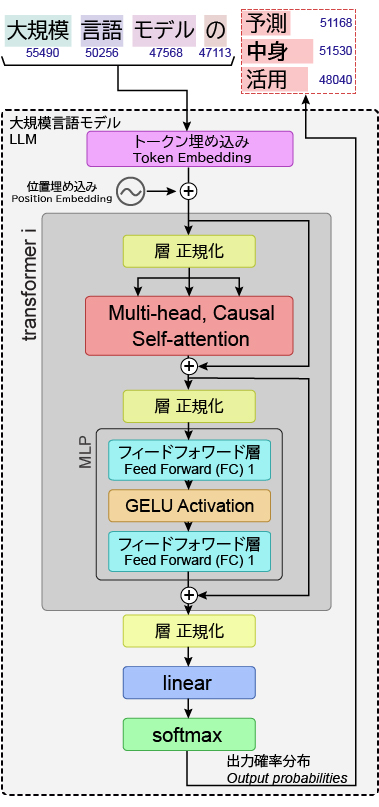

---

# 📦 ステップ1: 準備（ライブラリの読み込み）

## 🤔 ライブラリって何？

プログラムを書くときに便利な「道具箱」のようなものです。   
Pythonは、このような道具が大変充実していて、簡単に使えるので便利です。  
今回は、主に、以下の3つを使います。   

- **PyTorch**: AIを作るための道具
- **matplotlib**: グラフを描く道具
- **numpy**: 数値計算の道具

また、ファイル操作や時間に関するライブラリや、numpy (行列が得意なライブラリ)を使います。

下のセルを実行してください。▶ボタンを押すか、`Shift + Enter` で動きます。

In [ ]:
# 必要なライブラリを読み込む
import torch              # AI（ニューラルネットワーク）を作るための基本ツール
import torch.nn as nn     # ニューラルネットワークの部品
from torch.nn import functional as F  # よく使う関数たち
import os                 # 一般的なファイル操作
from datetime import datetime  # 時刻の表示
import matplotlib.pyplot as plt  # グラフを描く
import numpy as np        # 数値計算
from google.colab import files # ファイルをコラボから扱えるようにする。

torch.serialization.add_safe_globals([np.core.multiarray.scalar])

# 日本語フォント設定（グラフで日本語を表示するため）
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

# 実行環境の確認
print("="*70)
print("🎉 ライブラリの読み込み成功！")
print("="*70)
print(f"📅 実行開始時刻: {datetime.now().strftime('%Y年%m月%d日 %H:%M:%S')}")
print(f"🔧 PyTorchバージョン: {torch.__version__}")
print(f"💻 GPU（高速計算）は使える？ {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"   → 使えます！ GPU名: {torch.cuda.get_device_name(0)}")
    print(f"   → 学習が速くなります ⚡")
else:
    print(f"   → CPUで動きます（GPUより遅いですが問題なし）")

print("="*70)
print("✅ 準備完了！次のステップへ進みましょう")
print("="*70)

🎉 ライブラリの読み込み成功！
📅 実行開始時刻: 2026年06月14日 15:19:14
🔧 PyTorchバージョン: 2.11.0+cu128
💻 GPU（高速計算）は使える？ True
   → 使えます！ GPU名: Tesla T4
   → 学習が速くなります ⚡
✅ 準備完了！次のステップへ進みましょう


/tmp/ipykernel_637/749826139.py:11: DeprecationWarning: numpy.core is deprecated and has been renamed to numpy._core. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.
  torch.serialization.add_safe_globals([np.core.multiarray.scalar])


### ⚙️ ステップ2: AIの規模と学習方法を決める「設定ダイヤル」（ハイパーパラメータ）

まず、どのような規模のAIを作るのかを決める必要があります。具体的には、パラメータを大きくすれば表現力は上がるのですが、時間もかかりますし、データもたくさん必要になります。

また、AIの学習を始める前に、私たちはAIに「どんな風に、どこまで学習を進めるか」という学習戦略を指示する必要があります。
その学習戦略を決めるのが、このステップで設定するハイパーパラメータです。

### 🎛️ パラメータ と ハイパーパラメータ って何が違うの？
- パラメータ (AIが学習する数字) 🧠
例えるなら: AIの脳の中の「知識」や「神経細胞のつながり具合」。これは、生成AI(深層学習モデル)が学習の過程で自分で調整する何百万もの数字のことです。私たちは直接この値を設定しません。AIが訓練データから学んだ結果がこのパラメータになります。

- ハイパーパラメータ (人間が決める設定) 🧑‍💻
例えるなら: AIに渡す「勉強計画」や「学習方法の指示書」。
これは、学習が始まる前に人間が決定する設定値のことです。AIが「どのように」学習するかをコントロールします。
この次のコードセルで皆さんは設定する数値は、すべてハイパーパラメータです。

###📊 主なハイパーパラメータの解説
AIの性能を左右する重要な「調整ダイヤル」を、一つずつ見ていきましょう。

<details>
<summary><strong>1. データ処理に関する設定（勉強のやり方）</strong></summary>
<div>
<ul>
<li><code><strong>batch_size</strong></code>
<ul>
<li><strong>意味</strong>: 一度に何個の文章を見てから復習（パラメータ更新）するか。</li>
<li><strong>例え</strong>: 「練習問題を何問解いてから一度答え合わせをするか」。</li>
<li><strong>影響</strong>: 値を大きくすると、GPUの並列計算能力を活かせるため<strong>学習は速く</strong>なりますが、一度に多くの情報を記憶する必要があるため<strong>メモリを大量に消費します（重い）</strong>。</li>
</ul>
</li>
<li><code><strong>block_size</strong></code>
<ul>
<li><strong>意味</strong>: 次の単語を予測するために、最大で何文字前までの文脈を読むか。</li>
<li><strong>例え</strong>: 「文章を読むときの短期記憶の長さ」。</li>
<li><strong>影響</strong>: 値を大きくすると、より長い文脈を理解できるようになるため賢くなりますが、その分計算が<strong>重く</strong>なります。</li>
</ul>
</li>
</ul>
</div>
</details>

<details>
<summary><strong>2. AIの構造に関する設定（AIの作り方）</strong></summary>
<div>
<ul>
<li><code><strong>n_embd</strong></code>
<ul>
<li><strong>意味</strong>: 一つの単語を表現するために、どれだけリッチな情報量（ベクトルの次元数）を持たせるか。</li>
<li><strong>例え</strong>: 「AIの語彙力や表現力の豊かさ」。</li>
<li><strong>影響</strong>: 値が大きいほど、単語の持つ複雑なニュアンスを表現できますが、モデルが大きくなり計算が<strong>重く</strong>なります。</li>
</ul>
</li>
<li><code><strong>n_layer</strong></code>
<ul>
<li><strong>意味</strong>: Transformerの思考ユニット（Block）を何層重ねるか。</li>
<li><strong>例え</strong>: 「思考の深さ」や「脳の階層の数」。</li>
<li><strong>影響</strong>: 層が深いほど、より複雑なパターンを扱えるようになりますが、学習が難しくなり、計算も<strong>重く</strong>なります。</li>
</ul>
</li>
<li><code><strong>n_head</strong></code>
<ul>
<li><strong>意味</strong>: アテンション機構において、いくつの異なる視点から単語間の関連性を分析するか。</li>
<li><strong>例え</strong>: 「物事を分析するときの視点の数」。文法的な視点、意味的な視点など、複数の専門家がいるイメージ。</li>
</ul>
</li>
<li><code><strong>dropout</strong></code>
<ul>
<li><strong>意味</strong>: 学習中にAIの脳の一部（ニューロン）をランダムに休ませる割合。</li>
<li><strong>例え</strong>: 「あえて情報を一部忘れることで、丸暗記を防ぐ訓練」。</li>
<li><strong>影響</strong>: <strong>過学習（特定の練習問題だけを記憶してしまうこと）を防ぐ</strong>効果があります。値を大きくしすぎると、逆に学習が進まなくなります。</li>
</ul>
</li>
</ul>
</div>
</details>

<details>
<summary><strong>3. より高度な学習テクニックの設定 🚗💨</strong></summary>
<div>
<h4>Learning Rate Scheduler（学習率スケジューラ）</h4>
<p><strong>学習のペースを自動で調整する仕組みです。</strong></p>
<ul>
<li><strong>例え</strong>: 車の運転。最初はゆっくり発進し（ウォームアップ）、スピードに乗ったら一定速度で走り、目的地に近づいたら減速して丁寧に駐車します（減衰）。</li>
<li><code><strong>learning_rate</strong></code>: 学習の歩幅の初期値。</li>
<li><code><strong>warmup_iters</strong></code>: ゆっくりと学習ペースを上げていく助走期間。</li>
<li><code><strong>min_lr</strong></code>: 最終的に到達する最小の学習ペース。</li>
</ul>
<h4>Gradient Clipping（勾配クリッピング）</h4>
<p><strong>学習が「暴走」するのを防ぐ安全装置です。</strong></p>
<ul>
<li><strong>例え</strong>: 車のスピードリミッター。どんなにアクセルを踏んでも、決まった速度以上は出ないようにします。</li>
<li><strong>効果</strong>: 学習中に計算結果が異常に大きくなってモデルが壊れるのを防ぎ、<strong>学習を安定させます</strong>。</li>
</ul>
<h4>Weight Decay（重み減衰）</h4>
<p><strong>AIが答えを丸暗記（過学習）するのを防ぐ仕組みです。</strong></p>
<ul>
<li><strong>例え</strong>: テスト勉強で、答えそのものではなく「解き方」を理解しようとすること。</li>
<li><strong>効果</strong>: パラメータの値が大きくなりすぎるのにペナルティを与え、モデルがよりシンプルで**汎用的な解（未知のデータにも対応できる能力）**を見つけるのを助けます。</li>
</ul>
</div>
</details>

💡 実験してみよう！
これらのハイパーパラメータは、AIの性能を最大限に引き出すための「最高の組み合わせ」を探すための調整ダイヤルです。まずはこのまま実行してみて、学習の様子を観察しましょう。その後、可能であればこれらの値を少しずつ変えてAIの挙動がどう変わるか実験してみましょう！

In [ ]:
# ==============================================================================
# 🎛️ ここを変更して実験できます！
# ==============================================================================

# --- データ処理の設定 ---
batch_size = 64       # 一度に何個の文章を学習する？（大→速いが重い、小→遅いが軽い）
block_size = 128      # 何文字分を一度に見る？（大→長い文脈、小→短い文脈）

# --- 学習の設定 ---
max_iters = 5000      # 何回繰り返し学習する？（これは上限。実際は下の「3つのブレーキ」で早めに止まります）
eval_interval = 100   # 何回ごとに成績をチェックする？
learning_rate = 3e-4  # 学習速度の初期値
eval_iters = 20       # 評価の精度（100→20に削減。評価は推定値で十分＝大幅な高速化）

# --- AIの構造 ---
n_embd = 256         # アタマのサイズ
n_head = 8            # 何個の視点で見る？
n_layer = 8           # 何層で思考？
dropout = 0.1         # 過学習防止

# Learning Rate Scheduler設定
warmup_iters = 100          # ウォームアップ期間（最初100回はゆっくり学習）
lr_decay_iters = max_iters  # 減衰期間（全体で徐々に減速）
min_lr = 6e-5               # 最小学習率（初期の1/10まで下げる）

# Gradient Clipping設定
grad_clip = 1.0       # 勾配の最大値（これ以上大きくならない）

# Weight Decay設定
weight_decay = 1e-1   # L2正則化の強さ（0.1 = やや強め）

# --- チェックポイント（途中経過の保存）---
checkpoint_intervals = [1, 50, 100, 200, 400, 750]  # 最初は細かく保存
checkpoint_interval_regular = 250  # 750回以降は250回ごと
checkpoint_dir = 'checkpoints'     # 保存先フォルダ

# --- 自動停止の設定（30分以内に終わらせるための「3つのブレーキ」）---
target_val_loss = 1.6   # ① Val Loss がこの値まで下がったら「十分賢い」とみなして打ち切り
patience = 3            # ② 改善しない評価がこの回数つづいたら（＝下げ止まり）打ち切り
min_delta = 0.02        # 「改善した」とみなす最小の下げ幅（これ未満はプラトー扱い）
time_budget_min = 25    # ③ 学習の時間上限（分）。超えたら安全に打ち切り（生成・グラフの余白を残す）

# ==============================================================================

# 計算デバイスの決定（GPUがあればGPU、なければCPU）
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 🚀 高速化（混合精度 AMP）の設定 -----------------------------------------
# GPUなら半精度で計算して2〜3倍高速化＆省メモリ。
# T4（無料Colab）はbf16非対応なので、fp16(+GradScaler) を自動で選びます。
use_amp = (device == 'cuda')
amp_dtype = torch.bfloat16 if (use_amp and torch.cuda.is_bf16_supported()) else torch.float16
use_compile = False   # torch.compile。T4では不安定なことがあるので既定OFF（安定環境ならTrueで更に高速）

# 行列演算を少し速く（TF32の許可。T4では効果は小さいが無害）
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
# ---------------------------------------------------------------------------

# 設定の表示
print("\n" + "="*70)
print("⚙️  ハイパーパラメータ設定")
print("="*70)

print(f"\n🖥️  【実行環境】")
print(f"   計算デバイス: {device}")
if device == 'cuda':
    print(f"   💨 GPUで高速実行します！")
    print(f"   🔬 混合精度: {'bf16' if amp_dtype==torch.bfloat16 else 'fp16'}（自動選択）")
else:
    print(f"   🐢 CPUで実行します（GPUより遅いですが動きます）")

print(f"\n📦 【データ処理】")
print(f"   バッチサイズ: {batch_size} 個")
print(f"   コンテキスト長: {block_size} 文字")
print(f"   → 一度に{batch_size}個の{block_size}文字の文章を学習")

print(f"\n🧠 【AIの構造】")
print(f"   埋め込み次元: {n_embd} ")
print(f"   Attention Head: {n_head} 個")
print(f"   Transformer層: {n_layer} 層")
print(f"   Dropout率: {dropout}")
print(f"   → 予想パラメータ数: 約{(n_embd * n_embd * n_layer * 12) / 1e6:.1f}M個")

print(f"\n📚 【学習設定】")
print(f"   初期学習率: {learning_rate} ")
print(f"   最大イテレーション: {max_iters:,} 回 ")
print(f"   評価間隔: {eval_interval} 回ごと")

print(f"\n🆕 【高速化＆改善版の機能】")
print(f"   ⚡ 混合精度学習(AMP) + Flash Attention(SDPA)で高速化")
print(f"   ⚡ データをGPU常駐＋評価回数を削減して更に高速化")
print(f"   1️⃣ Learning Rate Warmup + Cosine Decay")
print(f"   2️⃣ Gradient Clipping (max={grad_clip})")
print(f"   3️⃣ Weight Decay (L2={weight_decay}、1次元パラメータは除外)")
print(f"   4️⃣ 重み共有(weight tying) + GELU + スケール初期化")

print(f"\n💾 【チェックポイント】")
print(f"   初期保存タイミング: {checkpoint_intervals}")
print(f"   以降の保存間隔: {checkpoint_interval_regular} 回ごと")

print(f"\n⏹️  【自動ストップ（3つのブレーキ）】")
print(f"   ① 目標Val Loss: {target_val_loss}（到達したら終了）")
print(f"   ② 下げ止まり: {patience} 回連続で改善なし（改善判定 {min_delta}）")
print(f"   ③ 時間上限: {time_budget_min} 分")

print("\n" + "="*70)
print("✅ 設定完了！次はデータを見てみましょう")
print("="*70)

# フォルダ作成
os.makedirs(checkpoint_dir, exist_ok=True)



⚙️  ハイパーパラメータ設定

🖥️  【実行環境】
   計算デバイス: cuda
   💨 GPUで高速実行します！
   🔬 混合精度: bf16（自動選択）

📦 【データ処理】
   バッチサイズ: 64 個
   コンテキスト長: 128 文字
   → 一度に64個の128文字の文章を学習

🧠 【AIの構造】
   埋め込み次元: 256 
   Attention Head: 8 個
   Transformer層: 8 層
   Dropout率: 0.1
   → 予想パラメータ数: 約6.3M個

📚 【学習設定】
   初期学習率: 0.0003 
   最大イテレーション: 5,000 回 
   評価間隔: 100 回ごと

🆕 【高速化＆改善版の機能】
   ⚡ 混合精度学習(AMP) + Flash Attention(SDPA)で高速化
   ⚡ データをGPU常駐＋評価回数を削減して更に高速化
   1️⃣ Learning Rate Warmup + Cosine Decay
   2️⃣ Gradient Clipping (max=1.0)
   3️⃣ Weight Decay (L2=0.1、1次元パラメータは除外)
   4️⃣ 重み共有(weight tying) + GELU + スケール初期化

💾 【チェックポイント】
   初期保存タイミング: [1, 50, 100, 200, 400, 750]
   以降の保存間隔: 250 回ごと

⏹️  【Early Stopping】
   忍耐力: 20 回 
   改善判定: 0.001

✅ 設定完了！次はデータを見てみましょう


---

# 📚 ステップ3: データの読み込み

## 📖 AIに何を教える？

AIは**たくさんの文章を読んで**日本語を学びます。
今回は夏目漱石の「こころ」をひらがなにしたものを使います。

### 📋 準備（下のセルを実行すると、この順で聞かれます）
1. このセルを実行する
2. 学習させたい文章のタイトルを番号で選ぶ（Shakespeare／夏目漱石 など）
3. 自分のテキストで試したい場合は `input.txt` をアップロード

※ アップロードしなければ、サンプルデータでそのまま進みます

In [ ]:
# ======================================================================
# 📖 ファイルアップロード機能
# ======================================================================
print("="*70)
# ユーザーが有効な選択をするまでループ
while True:
    print("--- 📖 入力データのタイトルを選択してください ---")
    print("  1: Shakespeare")
    print("  2: 夏目漱石")
    print("  3: 夏目漱石：濁点・半濁点分離")
    print("  4: その他（任意のタイトルを入力）")

    choice = input("番号を入力してください >>> ")

    if choice == '1':
        input_title = "Shakespeare"
        break # ループを抜ける
    elif choice == '2':
        input_title = "夏目漱石"
        break # ループを抜ける
    elif choice == '3':
        input_title = "夏目漱石：濁点・半濁点分離"
        break # ループを抜ける
    elif choice == '4':
        # 「その他」が選ばれた場合、任意のタイトルを入力させる
        input_title = input("その他のタイトルを文字列で入力し、教員に教えて下さい >>> ")
        break # ループを抜ける
    else:
        # 1, 2, 3 以外が入力された場合
        print("\n⚠️ 1, 2, 3, 4のいずれかの番号を入力してください。\n")

# 決定したタイトルを表示
print(f"\n✅ タイトルが「{input_title}」に設定されました。")
print("="*70)
print("📂 'input.txt' として使用したいテキストファイルをアップロードしてください")
print("   アップロードしない場合、サンプルデータで処理が続行されます。")
print("="*70)

# ファイルアップロードのダイアログを表示
uploaded = files.upload()



# アップロードされたファイルがあれば、その内容を 'input.txt' という名前で保存
if uploaded:
  # アップロードされた最初のファイル名を取得
  file_name = next(iter(uploaded))
  # ファイルの内容（バイナリ）を取得
  file_content = uploaded[file_name]

  # 'input.txt' にバイナリモードで書き込む
  with open('input.txt', 'wb') as f:
    f.write(file_content)

  print(f"\n✅ '{file_name}' をアップロードし、'input.txt' として保存しました！")
  print("   これ以降の処理はアップロードされたデータを使用します。")
else:
  print("\n⚠️ ファイルはアップロードされませんでした。")
  print("   サンプルデータまたは、すでにアップロードしていたファイルを使用して処理を続行します。")

# ======================================================================
# 📖 データ読み込み (元のコード)
# ======================================================================
print("\n" + "="*70)
print("📖 データ読み込み中...")
print("="*70)

# ファイルの読み込み
if os.path.exists('input.txt'):
    with open('input.txt', 'r', encoding='utf-8') as f:
        text = f.read()
    print("✅ input.txt を読み込みました！")
else:
    print("⚠️  input.txt が見つかりません")
    print("   サンプルデータで動かします")
    print("   本格的な学習には input.txt をアップロードしてください\n")
    text = """わたくしは そのひとを つねに せんせいと よんでいた。 だから ここでも ただ せんせいと かくだけで ほんみょうは うちあけない。 これは せけんを はばかる えんりょという よりも、 そのほうが わたくしに とって しぜんだから である。
わたくしは そのひとの きおくを よびおこす ごとに、 すぐ せんせいと いいたく なる。 ふでを とっても こころもちは おなじ ことで ある。 よそよそしい かしらもじなどは とても つかう きに ならない。""" * 20

# 基本的な統計
print(f"\n📊 データの基本情報")
print("-"*70)
print(f"総文字数: {len(text):,} 文字")
print(f"バイト数: {len(text.encode('utf-8')):,} bytes")

# どんな文字が使われているか
chars = sorted(list(set(text)))
vocab_size = len(chars)

print(f"\n🔤 使われている文字の種類: {vocab_size} 種類")
print("   ↓ これがAIの「語彙」になります\n")

# すべての文字を10個ずつ表示
print("【すべての文字（トークン）一覧】")
print("-"*70)
for i in range(0, len(chars), 10):
    chunk = chars[i:i+10]
    display = ' '.join([f"{char}({i+j})" for j, char in enumerate(chunk)])
    print(f"{i:3d}-{min(i+9, len(chars)-1):3d}: {display}")
print("-"*70)

print("\n" + "="*70)
print("✅ データ読み込み完了！")
print("="*70)

--- 📖 入力データのタイトルを選択してください ---
  1: Shakespeare
  2: 夏目漱石
  3: 夏目漱石：濁点・半濁点分離
  4: その他（任意のタイトルを入力）
番号を入力してください >>> 3

✅ タイトルが「夏目漱石：濁点・半濁点分離」に設定されました。
📂 'input.txt' として使用したいテキストファイルをアップロードしてください
   アップロードしない場合、サンプルデータで処理が続行されます。


Saving 3_夏目漱石_濁点・半濁点分離_input.txt to 3_夏目漱石_濁点・半濁点分離_input.txt

✅ '3_夏目漱石_濁点・半濁点分離_input.txt' をアップロードし、'input.txt' として保存しました！
   これ以降の処理はアップロードされたデータを使用します。

📖 データ読み込み中...
✅ input.txt を読み込みました！

📊 データの基本情報
----------------------------------------------------------------------
総文字数: 1,790,079 文字
バイト数: 4,682,269 bytes

🔤 使われている文字の種類: 70 種類
   ↓ これがAIの「語彙」になります

【すべての文字（トークン）一覧】
----------------------------------------------------------------------
  0-  9: 
(0)  (1) K(2) 、(3) 。(4) 「(5) 」(6) ぁ(7) あ(8) ぃ(9)
 10- 19: い(10) ぅ(11) う(12) ぇ(13) え(14) ぉ(15) お(16) か(17) き(18) く(19)
 20- 29: け(20) こ(21) さ(22) し(23) す(24) せ(25) そ(26) た(27) ち(28) っ(29)
 30- 39: つ(30) て(31) と(32) な(33) に(34) ぬ(35) ね(36) の(37) は(38) ひ(39)
 40- 49: ふ(40) へ(41) ほ(42) ま(43) み(44) む(45) め(46) も(47) ゃ(48) や(49)
 50- 59: ゅ(50) ゆ(51) ょ(52) よ(53) ら(54) り(55) る(56) れ(57) ろ(58) わ(59)
 60- 69: を(60) ん(61) ゛(62) ゜(63) ヴ(64) ー(65) ！(66) （(67) ）(68) ？(69)
----------------------------------------------------------------------

✅ データ読

## 📝 実際のテキストを見てみよう

In [ ]:
print("\n" + "="*70)
print("📝 学習データのサンプル（最初の300文字）")
print("="*70)
print(text[:300])
print("="*70)
print(f"\n💭 AIはこんな文章を何千回も読んで学習します")
print(f"   そして、同じような文章を書けるようになります！")


📝 学習データのサンプル（最初の300文字）
なつめ そうせき 「こころ」
し゛ょう せんせい と わたし
いち
わたくしは そのひとを つねに せんせいと よんて゛いた。 た゛から ここて゛も たた゛ せんせいと かくた゛けて゛ ほんみょうは うちあけない。 これは せけんを はは゛かる えんりょと いうよりも、 そのほうか゛ わたくしに とって しせ゛んた゛からて゛ある。 わたくしは そのひとの きおくを よひ゛おこすこ゛とに、 すく゛ 「せんせい」と いいたくなる。 ふて゛を とっても きもちは おなし゛ことて゛ある。 よそよそしい かしらもし゛なと゛は とても つかうきに ならない。
わたくしか゛ せんせいと しりあいに なったの

💭 AIはこんな文章を何千回も読んで学習します
   そして、同じような文章を書けるようになります！


## 📊 データの可視化

どんな文字がよく使われているか見てみましょう

In [ ]:
# Colab で日本語フォントをインストール→Matplotlib に登録
import os
!apt-get -y install fonts-noto-cjk fonts-ipafont-gothic > /dev/null

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

# 候補パス（環境にあるものだけ使う）
candidates = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJKjp-Regular.otf",
    "/usr/share/fonts/truetype/ipafont-gothic/ipag.ttf",   # IPAゴシック
    "/usr/share/fonts/truetype/ipafont-gothic/ipagp.ttf",
]

font_path = next((p for p in candidates if os.path.exists(p)), None)
assert font_path, "日本語フォントが見つかりませんでした。apt のログを確認してください。"

# フォントを明示登録してから family を設定
fm.fontManager.addfont(font_path)
jp_name = fm.FontProperties(fname=font_path).get_name()
rcParams["font.family"] = jp_name
rcParams["axes.unicode_minus"] = False

print("Using JP font:", jp_name, "at", font_path)
print("✅ グラフに用いるフォントを定義しました")

Using JP font: Noto Sans CJK JP at /usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc
✅ グラフに用いるフォントを定義しました


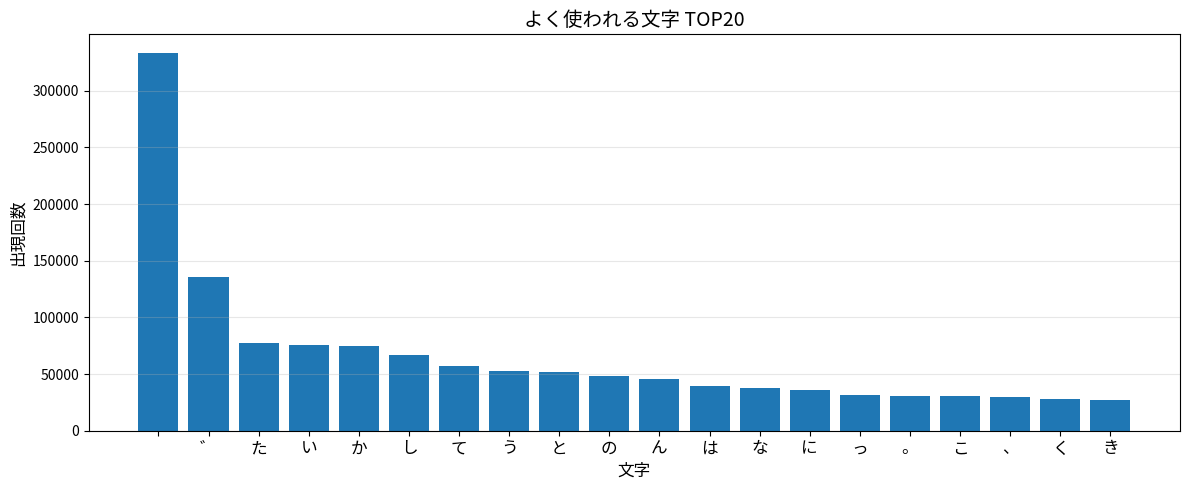


📊 よく使われる文字 TOP10:
--------------------------------------------------
 1. ' ': 333,131回 ██████████████████████████████
 2. '゛': 136,066回 ████████████
 3. 'た': 76,995回 ██████
 4. 'い': 75,274回 ██████
 5. 'か': 75,057回 ██████
 6. 'し': 66,779回 ██████
 7. 'て': 56,899回 █████
 8. 'う': 52,270回 ████
 9. 'と': 52,130回 ████
10. 'の': 48,662回 ████
--------------------------------------------------

💡 AIはこの頻度も学習します！


In [ ]:
# 文字の出現頻度を数える
from collections import Counter

char_counts = Counter(text)
most_common = char_counts.most_common(20)

chars_plot = [c[0] for c in most_common]
counts_plot = [c[1] for c in most_common]

plt.figure(figsize=(12, 5))
plt.bar(range(len(chars_plot)), counts_plot)
plt.xticks(range(len(chars_plot)), chars_plot, fontsize=12)
plt.xlabel('文字', fontsize=12)
plt.ylabel('出現回数', fontsize=12)
plt.title('よく使われる文字 TOP20', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 よく使われる文字 TOP10:")
print("-"*50)
for i, (char, count) in enumerate(most_common[:10], 1):
    bar = '█' * int(count / most_common[0][1] * 30)
    print(f"{i:2d}. '{char}': {count:6,}回 {bar}")
print("-"*50)
print("\n💡 AIはこの頻度も学習します！")

---

# 🔢 ステップ4: エンコード・デコード

## 🤖 AIは文字を読めない！？

実は、コンピュータは**数字しか理解できません**。
そこで、文字を数字に変換する必要があります。

```
文字 → 数字 : エンコード（encode）
数字 → 文字 : デコード（decode）
```

実際に見てみましょう！

In [ ]:
# エンコード・デコード関数の作成
stoi = {ch: i for i, ch in enumerate(chars)}  # string to index（文字→数字）
itos = {i: ch for i, ch in enumerate(chars)}  # index to string（数字→文字）

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print("\n" + "="*70)
print("🔢 エンコード・デコードのデモ")
print("="*70)

def get_sample_text(char_list: list) -> str:
    """
    文字の「リスト」に全てのアルファベット、または全てのひらがなが含まれるか判定し、
    条件に応じたサンプルテキストを返す。
    """

    # 判定用の文字セットを定義
    alphabet = set('abcdefghijklmnopqrstuvwxyz')
    hiragana = set('あいうえおかきくけこさしすせそたちつてとなにぬねのはひふへほまみむめもやゆよらりるれろわをん')

    # === 修正箇所 ===
    # リスト内の各文字を小文字に変換してから、全体のセットを作成する
    input_chars = set(c.lower() for c in char_list if isinstance(c, str))

    # --- 条件判定 ---

    # 1. 全てのアルファベットが含まれるかチェック
    if alphabet.issubset(input_chars):
        print("✅ 全てのアルファベットを検出しました。")
        sample_text = "Hello world"
        return sample_text

    # 2. 全てのひらがなが含まれるかチェック
    elif hiragana.issubset(input_chars):
        print("✅ 全てのひらがなを検出しました。")
        sample_text = "わか゛はいは ねこて゛ ある"
        return sample_text

    # 3. どちらの条件にも当てはまらない場合
    else:
        print("⚠️ 条件に合う文字セットではありません。")
        return "条件に合致しませんでした" # Noneの代わりにメッセージを返すように変更

sample_text = get_sample_text(chars)
encoded_sample = encode(sample_text)
decoded_sample = decode(encoded_sample)

print(f"\n【元の文字列】")
print(f"   {sample_text}")

print(f"\n【エンコード（文字 → 数字）】")
print("-"*70)
for i, char in enumerate(sample_text):
    num = encoded_sample[i]
    print(f"   '{char}' → {num:3d}")

print(f"\n【数字の並び】")
print(f"   {encoded_sample}")
print(f"   ↑ AIはこの数字の並びを見て学習します！")

print(f"\n【デコード（数字 → 文字）】")
print(f"   {decoded_sample}")
print(f"   ↑ 元通りになりました！")

print("\n" + "="*70)
print("✅ エンコード・デコードの仕組みが理解できました")
print("="*70)


🔢 エンコード・デコードのデモ
✅ 全てのひらがなを検出しました。

【元の文字列】
   わか゛はいは ねこて゛ ある

【エンコード（文字 → 数字）】
----------------------------------------------------------------------
   'わ' →  59
   'か' →  17
   '゛' →  62
   'は' →  38
   'い' →  10
   'は' →  38
   ' ' →   1
   'ね' →  36
   'こ' →  21
   'て' →  31
   '゛' →  62
   ' ' →   1
   'あ' →   8
   'る' →  56

【数字の並び】
   [59, 17, 62, 38, 10, 38, 1, 36, 21, 31, 62, 1, 8, 56]
   ↑ AIはこの数字の並びを見て学習します！

【デコード（数字 → 文字）】
   わか゛はいは ねこて゛ ある
   ↑ 元通りになりました！

✅ エンコード・デコードの仕組みが理解できました


## 🎯 もっと詳しく見てみよう

In [ ]:
# 全データをエンコード
data = torch.tensor(encode(text), dtype=torch.long)

print(f"\n📊 エンコード後のデータ")
print("-"*70)
print(f"形状: {data.shape}")
print(f"データ型: {data.dtype}")

print(f"\n最初の50個の数字:")
print(data[:50])

print(f"\nこれを文字に戻すと...")
print(decode(data[:50].tolist()))

print("\n💡 ポイント")
print("   - すべての文章が数字の列になりました")
print("   - この数字の並びから次に来る数字を予測するのがAIの仕事！")


📊 エンコード後のデータ
----------------------------------------------------------------------
形状: torch.Size([1790079])
データ型: torch.int64

最初の50個の数字:
tensor([33, 30, 46,  1, 26, 12, 25, 18,  1,  5, 21, 21, 58,  6,  0, 23, 62, 52,
        12,  1, 25, 61, 25, 10,  1, 32,  1, 59, 27, 23,  0, 10, 28,  0, 59, 27,
        19, 23, 38,  1, 26, 37, 39, 32, 60,  1, 30, 36, 34,  1])

これを文字に戻すと...
なつめ そうせき 「こころ」
し゛ょう せんせい と わたし
いち
わたくしは そのひとを つねに 

💡 ポイント
   - すべての文章が数字の列になりました
   - この数字の並びから次に来る数字を予測するのがAIの仕事！


### 補足🧠：実は、本当の生成AIは文字ごとにトークン化していないです…

このように、生成AIの出力単位ごとにコードやベクトルを当てることを、トークン化といいます。この授業で扱うAIは、トークンを1文字ごとに当てています。
でも、実際の生成AIは、トークン化の方法が少し違います。

#### なぜ「文字ごと」ではダメ？
文字ごとの処理はシンプルですが、大規模なAIにはいくつかの弱点があります。
- 意味の単位が小さすぎる: 「り」「ん」「ご」のように1文字ずつ見ても、それが果物の「林檎」だとは分かりにくいです。AIは「り」「ん」「ご」という文字の並びから「林檎」の意味をゼロから学習せねばならず、非常に大変で効率が悪いです。
- 文章が長くなりすぎる: 「私は猫です」は7文字なので[1, 2, 3, 4, 5, 6, 7]のように7つの数字になります。これが長い論文だと、とてつもなく長い数字の列になり、計算が非常に重くなってしまいます。

#### 現代AIの解決策：サブワード・トークン化
そこで、ほとんどの現代AIは「サブワード（Subword）」という方法を使います。これは、文字と単語の"いいとこ取り"をしたような手法です。   

サブワードは、文章を以下のように分割します。   
- よく使われる単語は、そのまま1つのトークン（1つの数字）にします。
   - "apple" → ["apple"]
- あまり使われない単語や長い単語は、意味のあるパーツに分解します。
   - "unforgettable" → ["un", "forget", "able"]
   - "トークン化" → ["トークン", "化"]
- 未知の単語でも、知っているパーツに分解して対応できます。
   - "GPT-4" → ["G", "PT", "-", "4"]

#### サブワードの利点
- 効率が良い: 「apple」が5文字（5つの数字）ではなく、1つの単語（1つの数字）で済むため、処理する数字の列が短くなり、計算が速くなります。
- 未知の単語に強い: 辞書にない新しい言葉や造語（例: shin-godzilla）が出てきても、["shin", "-", "godzilla"]のように分解できるため、意味を推測しやすくなります。「語彙にない」という問題が起きません。
- 意味を捉えやすい: un-（〜ない）や-able（〜できる）のような接頭辞・接尾辞もパーツとして学習するため、単語の構造まで扱えるようになります。

詳しく知りたい方は、トーカナイザーを調べてみましょう。

<details>
  <summary><strong>トーカナイザーの役割「ID番号への変換」</strong></summary>
  <div>
    <p>トーカナイザーは、巨大な「単語帳（語彙リスト）」を持っていて、文章をその単語帳に載っているID番号に置き換えるのが仕事です。</p>
    <p><strong>処理の流れ</strong></p>
    <ul>
      <li><strong>入力:</strong> 「猫が大好き」 (文章)</li>
      <li><strong>分割:</strong> ["猫", "が", "大好き"] (トークンに分割)</li>
      <li><strong>出力:</strong> [8182, 12, 13456] (ID番号のリスト)</li>
    </ul>
    <p>この時点での数字は、単なる識別番号です。「猫」という単語は単語帳の8182番目にある、という以上の意味はありません。この数字自体には、単語の意味や文脈は含まれていません。</p>
  </div>
</details>

## ✂️ データの分割

### なぜデータを「訓練用」と「検証用」に分けるのか？ 📝

AIの学習を、あなたがテスト勉強をする場面に例えてみましょう。

  * **全データ**: あなたが勉強に使える「問題集一式」
  * `train_data` (**訓練データ**): 勉強に使う「教科書」や「練習問題」 (全体の90%)
  * `val_data` (**検証データ**): 実力を試すための「模擬試験」 (全体の10%)

AIも人間と同じで、ただ答えを丸暗記するだけでは、本当に力がついたとは言えません。そこで、データを2つに分けて、AIの本当の実力を測る必要があります。

-----

#### 過学習 (Overfitting) とは？ 🧠❌

**過学習**とは、AIが訓練データを**丸暗記しすぎてしまう**状態のことです。

テスト勉強で例えると、練習問題の答えを問題の順番や数字まで完璧に覚えてしまうようなものです。その結果、練習問題では100点が取れるのに、数字や聞き方が少し変わっただけの模擬試験では全く点数が取れなくなってしまいます。

AIも同じで、訓練データに出てきたパターンに過剰に適合（フィット）しすぎてしまうと、未知のデータに対して全く対応できなくなります。これでは「頭が固いAI」になってしまいます。

-----

#### 汎化 (Generalization) とは？ 🧠⭕️

**汎化**とは、AIが訓練データから学んだ知識を、**未知のデータにも応用できる**能力のことです。

テスト勉強で言えば、練習問題を通して公式や解き方の「本質」を理解し、模擬試験で初めて見る問題でもスラスラ解ける状態です。これこそが目指したい状態です。

AI開発の最終目標は、この**汎化性能** (汎化能力) を高くすることです。

-----

#### 賢いAIを作るための戦略

```python
# データを90%と10%に分割
n = int(0.9 * len(data))
train_data = data[:n] # AIが勉強するための「練習問題」
val_data = data[n:]   # AIの実力を測るための「模擬試験」
```

そこで、このデータ分割のステップがあります。
AIが過学習に陥っていないかを確認し、汎化性能を正しく評価するために不可欠なステップです。

1.  AIは`train_data` (練習問題) で一生懸命勉強します。
2.  私たちは、AIが勉強に使っていない`val_data` (模擬試験) で時々テストをします。
3.  この「模擬試験」の成績が良ければ、AIはちゃんと**汎化**できていると判断できます。
4.  もし「練習問題」の成績は良いのに「模擬試験」の成績が悪い場合は、AIが**過学習**しているサインです。

このようにデータを分割することで、モデルを、ただの"丸暗記マシン"ではなく、未知のデータにも通用するものに仕上げることができます。

In [ ]:
# データを90%と10%に分割
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

# 🚀 データをまるごとGPUに常駐させる（毎ステップのCPU→GPU転送をなくして高速化）
#    文字データは軽いのでGPUメモリにそのまま載せられます。
train_data = train_data.to(device)
val_data = val_data.to(device)

print("\n" + "="*70)
print("✂️  データの分割")
print("="*70)

print(f"\n📚 訓練データ: {len(train_data):,} 文字 ({len(train_data)/len(data)*100:.1f}%)")
print(f"📝 検証データ: {len(val_data):,} 文字 ({len(val_data)/len(data)*100:.1f}%)")

train_blocks = int(len(train_data) / len(data) * 50)
val_blocks = 50 - train_blocks
print(f"\n訓練: {'█' * train_blocks}")
print(f"検証: {'█' * val_blocks}")
print(f"\n💾 データ配置: {train_data.device}（GPU常駐なら学習が速くなります）")
print("="*70)



✂️  データの分割

📚 訓練データ: 1,611,071 文字 (90.0%)
📝 検証データ: 179,008 文字 (10.0%)

訓練: ████████████████████████████████████████████
検証: ██████

💾 データ配置: cuda:0（GPU常駐なら学習が速くなります）


## 🎲 ミニバッチ関数の定義

### 🤔 なぜ「つまみ食い」が必要？
AIの学習に使うデータ（例えば、Web上の全テキスト）は、ものすごく巨大です。これを教科書に例えてみましょう。もしAIがこの巨大な教科書を全部一気に読んでから「よし、1ページ目の内容を覚え直そう」とすると、次のような問題が起きます。  

- 机（メモリ）に乗らない: 教科書が分厚すぎて、AIの勉強机であるコンピュータのメモリに全部乗り切りません。  
- 時間がかかりすぎる: 全部読み終わるまでに時間がかかりすぎて、全然勉強が進みません。最初の内容を忘れてしまいます。  

これでは効率が悪くて、学習がなかなか進みません。

### ✨ そこで「ミニバッチ」の登場！
そこで、賢い勉強法として「ミニバッチ学習」を使います。
get_batch という関数は、巨大な教科書からランダムに数ページだけをパッと抜き出してくる役割をします。この抜き出された小さなデータのかたまりがミニバッチです。
AIはこのミニバッチ（数ページ分のデータ）だけを集中して勉強します。
1. ミニバッチを読む（学習）
2. 内容を理解できたか簡単なテストをする（損失を計算）
3. 間違えたところを反省して、覚え直す（モデルを更新）

このサイクルを、教科書のいろんな場所から抜き出したミニバッチで何回も何回も繰り返します。

### 🚀 ミニバッチ学習のメリット
この「つまみ食い学習」には、いいことがたくさんあります。

- 速い！ 🚀
少しのデータでサクサク学習が進むので、すぐにフィードバックが得られ、学習が着実に進みます。

- メモリに優しい！ 💻
一度に扱うデータが小さいので、普通のコンピュータでも巨大なデータセットを学習できます。

- 汎化しやすくなる 🧠
毎回ランダムにデータを選ぶことで、AIはデータの順番を丸暗記するのではなく、文章の「パターン」や「法則」といった本質的なことを学べるようになります。これにより、未知の文章にも対応できる応用力が身につくのです。

まとめると、get_batch関数は、巨大なデータの中から学習用の小さな「お試しセット（ミニバッチ）」を効率よく準備するための、非常に重要な仕組みなんです。

In [ ]:
def get_batch(split):
    # 🚀 データはGPU常駐なので転送ゼロ。インデックスはCPUで作る（軽いのでこれが速い）
    data_source = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_source) - block_size, (batch_size,))
    x = torch.stack([data_source[i:i+block_size]   for i in ix])
    y = torch.stack([data_source[i+1:i+block_size+1] for i in ix])
    return x, y  # x, y はすでにGPU上（data_source がGPUにあるため）

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            # 🚀 評価も混合精度で（学習と条件を揃えつつ高速化）
            with torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_amp):
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

print("✅ データ処理関数を定義しました（GPU常駐＋混合精度評価で高速化）")


✅ データ処理関数を定義しました（GPU常駐＋混合精度評価で高速化）


---

# 🏗️ ステップ5: AIモデルの構築
ここでは、生成AIの核心となっているTransformerモデルが計算に使う、たくさんの **数字（パラメータ）を入れるための「器」や「設計図」** を 作っています。

### Transformerの正体：強力な「予測変換」システム   
あなたがスマホで「猫がマットの上で」と入力したとき、スマホの予測変換が「寝ている」や「座っている」を候補に出してくれますよね。Decoder-OnlyのTransformerは、これを大規模にしたものだと考えてください。
なにか入力を与えた時、次にくる文字を予測して生成するのが生成AIの仕組みです。
**予測した結果を次の入力に使えば、どんどん、文章が出来上がりますね。**

### 📜 まず歴史から：なぜTransformerはすごかったのか
2017年、Googleの研究者たちが「Attention is All You Need」という論文を発表しました。 それまで主流だったAI（RNNやLSTM）は、文章を前から順番に処理する仕組みが中心で、離れた単語どうしの関係や、計算の並列化が苦手でした。でもTransformerは「全部の単語を一度に見渡して、重要な関係を見つける」という革新的な方法を発明したのです。
その後、2018年にOpenAIがGPT（Generative Pre-trained Transformer）を発表。このときの論文は、Improving Language Understanding by Generative Pre-Training (Radford et al. 2018)です。   
リンク：https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf

Transformerの「デコーダー部分だけ」を使って、前から順に単語を予測する能力に特化させる。これが今のChatGPTの祖先となっています。

### 🏗️ このコードの全体像
このコードは、まさにそのGPTの心臓部を再現しています：   
```
入力テキスト      
    ↓  
📚 Embedding（単語を数字に変換）   
    ↓  
🔄 Block × n層（思考を深める）  
    ├─ MultiHeadAttention（単語同士の会話）   
    └─ FeedForward（一人での思索）  
    ↓  
🎯 出力層（次の単語を予測）  
```
大変シンプルなコードですが、これだけで、考え方の核心は包含されています。

In [ ]:
import math

class Head(nn.Module):  # Self-Attentionの単一のヘッド（1つの視点）を定義するクラス
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # 🚀 マスク・スケーリング・softmax・dropout は SDPA が内部で処理するので
        #    tril バッファは不要になりました（dropout率だけ覚えておく）
        self.dropout_p = dropout

    def forward(self, x):
        k = self.key(x)    # (B, T, head_size)
        q = self.query(x)  # (B, T, head_size)
        v = self.value(x)  # (B, T, head_size)

        # 🚀 Flash Attention 系の高速カーネル（因果マスク・1/sqrt(head_size)スケーリング込み）
        #    T4 では memory-efficient / math カーネルに自動フォールバックします。
        out = F.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.dropout_p if self.training else 0.0,
            is_causal=True,
        )
        return out  # (B, T, head_size)


class MultiHeadAttention(nn.Module):  # 複数のHeadを束ねて、多角的な視点からAttentionを計算するクラス
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out


class FeedForward(nn.Module):  # Attentionで集めた情報を処理・変換するフィードフォワードネットワーク
    def __init__(self, n_embd):
        super().__init__()
        self.fc   = nn.Linear(n_embd, 4 * n_embd)
        self.act  = nn.GELU()                       # 🆕 ReLU → GELU（GPTの標準活性化）
        self.proj = nn.Linear(4 * n_embd, n_embd)   # 出力projection（スケール初期化の対象）
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.dropout(self.proj(self.act(self.fc(x))))


class Block(nn.Module):  # Transformerの基本的な構成単位（思考の1サイクル）
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):  # 残差接続（Pre-LN）の実装
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class GPTLanguageModel(nn.Module):  # Transformerブロックを積み重ねたGPTのモデル全体
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        # 🆕 重み共有(weight tying)：入力埋め込みと出力層で重みを共有（汎化↑・パラメータ↓）
        self.token_embedding_table.weight = self.lm_head.weight

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -block_size:]
            logits, loss = self(idx_cond)
            logits = logits[:, -1, :] / temperature   # 🆕 温度（小さい=堅実, 大きい=奔放）
            if top_k is not None:                       # 🆕 上位k個だけからサンプリング＝崩れ防止
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('inf')
            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


def init_weights(module):  # パラメタの初期化
    """パラメータを適切に初期化"""
    if isinstance(module, nn.Linear):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            torch.nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)


# モデルのインスタンス化
model = GPTLanguageModel()
model.apply(init_weights)

# 🆕 残差に足し込む projection 層だけ小さく初期化（深い層でも安定：GPT-2流）
for pn, p in model.named_parameters():
    if pn.endswith('proj.weight'):
        torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))

print("初期化完了!")
m = model.to(device)

# 🚀 任意：torch.compile（T4では不安定なことがあるので use_compile で制御）
if use_compile:
    try:
        model = torch.compile(model)
        print("⚡ torch.compile を有効化しました")
    except Exception as e:
        print(f"⚠️ torch.compile は使えませんでした（そのまま継続します）: {e}")

# パラメータ数（重み共有のぶん、実質パラメータは少し減ります）
n_params = sum(p.numel() for p in m.parameters())

print("\n🤖 AIモデル完成！")
print(f"総パラメータ数: {n_params:,} 個 ({n_params/1e6:.2f}M)")
print(f"実行環境: {device}")


初期化完了!

🤖 AIモデル完成！
総パラメータ数: 6,363,136 個 (6.36M)
実行環境: cuda


AIの仕事はただ一つ、**「これまでの文脈を読んで、次に来る最もらしい単語を予測すること」**です。

そのために、AIは以下の3つのステップで処理を進めます。

<details>
<summary><strong>ステップ①：単語の「意味」と「順番」をベクトルに変換する（入力の準備）</strong></summary>
<div>
<h4>1. トークン・エンベディング（意味の辞書を引く）🔡</h4>
<p>AIは「猫」や「マット」という文字を直接理解できません。そこで、まず各単語を巨大な「<strong>意味の辞書</strong>」で引いて、その単語が持つ豊かな意味を表現した<strong>ベクトル（数字の配列）</strong>に変換します。</p>
<ul>
<li>この辞書では、「猫」と「犬」のベクトルは似た値になり、「猫」と「車」のベクトルは全く異なる値になります。</li>
</ul>
<h4>2. ポジショナル・エンベディング（順番の辞書を引く）📍</h4>
<p>次に、「これは1番目の単語」「これは2番目の単語」という<strong>位置情報</strong>もベクトルに変換します。文章では単語の順番が非常に重要だからです（「猫が魚を食べた」と「魚が猫を食べた」では大違いですよね）。</p>
<p><strong>ステップ①の結果</strong>: 各単語は「<strong>意味のベクトル</strong>」と「<strong>位置のベクトル</strong>」を足し合わせた、リッチな情報を持つベクトルになります。これがAIの思考の材料です。</p>
</div>
</details>

<details>
<summary><strong>ステップ②：文脈を読み解く「思考部屋」（Transformerブロック）</strong></summary>
<div>
<p>ここがTransformerの心臓部です。単語のベクトルたちが「思考部屋」に入り、2つの重要な活動を通して文脈を理解します。</p>
<h4><strong>活動A：マルチヘッド・アテンション（全員参加の井戸端会議）</strong>🗣️</h4>
<p><strong>役割</strong>: 各単語が、文中の他の単語と「対話」して、自分との関連性を探します。</p>
<p><strong>例</strong>: 「猫がマットの上で<strong>寝ている</strong>」という文の「寝ている」という単語は、この会議を通して「<strong>誰が</strong>寝ているの？ → <strong>猫が</strong>」という関連性を強く認識します。</p>
<ul>
<li><strong>マルチヘッド</strong>: この会議は、複数の視点（ヘッド）で同時に行われます。ある会議では「主語と述語の関係」が、別の会議では「場所との関係」が話し合われる、といったイメージです。</li>
<li><strong>Decoder-Onlyの特別ルール（未来は見ない！）</strong>: 文章を生成するAIなので、「カンニング」は厳禁です。各単語は、<strong>自分より前にある単語としか対話できません</strong>。これが<code>masked_fill</code>の役割です。</li>
</ul>
<h4><strong>活動B：フィードフォワード・ネットワーク（一人での深い思索）</strong>🤔</h4>
<p><strong>役割</strong>: 井戸端会議で得た豊富な文脈情報を、各単語が<strong>一人でじっくりと考え込む</strong>時間です。</p>
<p><strong>例</strong>: 「猫」という情報と強く結びついた「寝ている」のベクトルが、この思索プロセスを通して、より洗練された「ペットがリラックスしている状態」といった、より高度な概念を持つベクトルに変換されます。</p>
<p>AIは、この「<strong>会議 → 思索</strong>」のセット（Transformerブロック）を何層も積み重ねることで、どんどん深く文章を理解していきます。</p>
</div>
</details>

<details>
<summary><strong>ステップ③：次の単語を予測する（最終結論）</strong></summary>
<div>
<p>何層もの思考部屋を通り抜けた後、AIは最終的な結論を出します。</p>
<ol>
<li><strong>最後の単語に注目</strong>: 文の<strong>一番最後の単語</strong>のベクトルを取り出します。このベクトルには、これまでの文脈情報がすべて凝縮されています。</li>
<li><strong>次の単語の候補を採点</strong>: この最終ベクトルを使って、語彙（AIが知っている全単語）の中から、次に来る単語の候補を一つずつ採点（ロジットを計算）します。</li>
<li><strong>確率に変換 (Softmax)</strong>: 採点結果を「確率（パーセンテージ）」に変換します。
<ul>
<li>例: 「寝ている」が80%、「座っている」が15%、「走っている」が5%… といった具合です。</li>
</ul>
</li>
<li><strong>単語を選択</strong>: 確率に応じて次の単語を選びます（確率が高い「寝ている」が選ばれやすい）。確率で選ぶため、<strong>同じ入力でも毎回少し違う文</strong>になります。</li>
</ol>
<p>文章を生成する際は、この3ステップを何度も何度も繰り返します。「寝ている」を文末に追加したら、今度はその新しい文全体を使って、さらに次の単語を予測していくのです。</p>
</div>
</details>

# 補足：Transformerモデルの各論

## 🎯 Head - アテンションの基本単位


### 何をするもの？
**「この単語は、他のどの単語と関係が深いか？」を計算する部分**

### 解説

```python
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
```

#### 📝 ステップ1: 初期化（準備段階）
- **key（鍵）**: 「私はこんな情報を持っています」と宣伝する看板
- **query（質問）**: 「私はこんな情報が欲しいです」と探す虫眼鏡
- **value（値）**: 実際に渡す情報の中身

**例え話**: 図書館を想像してください
- **key** = 本の背表紙（「この本は恋愛小説です」）
- **query** = あなたの検索ワード（「恋愛小説」を探しています）
- **value** = 本の中身（実際に読む内容）

---

```python
self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
```

#### 📝 ステップ2: カンニング防止マスクの作成
**tril（下三角行列）**: 未来の単語を見えなくする装置

```
例: 「猫が」の次を予測するとき
見ていいもの: 「猫」「が」  ✅
見てはダメ: 「寝ている」   ❌（これは未来の答え！）
```

---

```python
def forward(self, x):
    B, T, C = x.shape
    k = self.key(x)
    q = self.query(x)
```

#### 📝 ステップ3: 入力を受け取って変換
- **B** = バッチサイズ（一度に処理する文章の数）
- **T** = 時間ステップ（文章の長さ）
- **C** = チャネル数（各単語の情報量）

**具体例**:
```
入力: 「猫が寝ている」
↓
各単語を key と query に変換
猫:   key=[0.2, 0.8, ...], query=[0.3, 0.5, ...]
が:   key=[0.1, 0.4, ...], query=[0.7, 0.2, ...]
```

---

```python
wei = q @ k.transpose(-2, -1) * C**-0.5
```

#### 📝 ステップ4: 関連度スコアの計算
**やっていること**: 全単語ペアの「相性度」を計算

**数学的な意味**:
- `q @ k.transpose(-2, -1)` = 内積（ベクトルの向きがどれだけ似ているか）
- `* C**-0.5` = スケーリング（数字が大きくなりすぎないように調整）

**実際の数値例**:
```
「猫」の query と 「寝ている」の key を掛け算
→ スコア = 0.8（強い関連性！）

「猫」の query と 「が」の key を掛け算
→ スコア = 0.2（弱い関連性）
```

---

```python
wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
wei = F.softmax(wei, dim=-1)
```

#### 📝 ステップ5: 未来をマスク＆確率に変換

**masked_fill**: 未来の単語のスコアを「-∞」に設定
```
処理前: [0.8, 0.2, 0.9] ← 0.9は未来の単語！
処理後: [0.8, 0.2, -∞]
```

**softmax**: スコアを「確率」に変換（合計が1になる）
```
処理後: [0.67, 0.33, 0.00] ← 未来は0%に！
```

---

```python
wei = self.dropout(wei)
v = self.value(x)
out = wei @ v
return out
```

#### 📝 ステップ6: 情報を集約して出力
**最終ステップ**: 確率 × 実際の情報 = 加重平均

**具体例**:
```
「寝ている」を予測するとき

猫の情報（value）:   [ふわふわ、4本足、...]  × 確率0.67
がの情報（value）:   [助詞、文法、...]      × 確率0.33
─────────────────────────────────────
= [重要な特徴だけを集めた情報] → 次の単語予測に使う！
```

---

---

## 👀 MultiHeadAttention - 複数の視点で見る

### 何をするもの？
**1つのHeadだけだと視点が偏る → 複数のHeadで多角的に分析**

```python
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)
```

#### 📝 ステップ1: 複数のHeadを作成
**なぜ複数必要？**

人間が文章を読むときのプロセスに似ています：
```
Head 1: 「誰が？」（主語に注目）
Head 2: 「何を？」（目的語に注目）
Head 3: 「どこで？」（場所に注目）
Head 4: 「いつ？」（時間に注目）
```

**例**:「昨日、太郎が公園で犬と遊んだ」
- Head 1 → 「太郎」に強く反応
- Head 2 → 「犬」「遊んだ」に強く反応
- Head 3 → 「公園」に強く反応
- Head 4 → 「昨日」に強く反応

---

```python
def forward(self, x):
    out = torch.cat([h(x) for h in self.heads], dim=-1)
    out = self.dropout(self.proj(out))
    return out
```

#### 📝 ステップ2: 各Headの結果を統合
**やっていること**:
1. 各Headが別々に分析 → 8個の視点が得られる
2. `torch.cat` で結合 → 1つの豊かな表現に
3. `proj` で次の層に適した形に変換
4. `dropout` でランダムに一部を無効化（過学習防止）

**視覚的に**:
```
Head 1の出力: [0.2, 0.8, 0.3, 0.5]
Head 2の出力: [0.1, 0.6, 0.9, 0.2]
Head 3の出力: [0.7, 0.3, 0.4, 0.8]
↓ 結合
統合された出力: [0.2, 0.8, 0.3, 0.5, 0.1, 0.6, 0.9, 0.2, 0.7, 0.3, 0.4, 0.8]
```



---

## 🔄 FeedForward - 知識の変換器

### 何をするもの？
**単語の組み合わせから、より抽象的な概念を学習する部分**

```python
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
```

#### 📝 ステップ1: 膨らんで縮む構造

**なぜこの構造？**

```
元のサイズ（今回は 256次元）
    ↓ 膨らむ
作業スペース（4倍の 1024次元） ← より複雑なパターンを捉える
    ↓ 縮む
元のサイズ（512次元） ← 重要な情報だけ残す
```

**例え話**: 料理のプロセス
1. **材料を広げる**（膨らむ）: 「猫」「寝る」「マット」を全部テーブルに並べる
2. **組み合わせを試す**（作業スペース）: いろんな組み合わせで「リラックスしているペット」という概念を発見
3. **完成品にまとめる**（縮む）: 重要なエッセンスだけ抽出

---

#### 📝 ステップ2: ReLU活性化関数

```python
nn.ReLU()  # Rectified Linear Unit
```

**何をする？**: 負の値を0にする

```
入力:  [-0.5, 0.3, -0.2, 0.8]
    ↓ ReLU
出力:  [0.0, 0.3, 0.0, 0.8]
```

**なぜ必要？**:
- 非線形性を追加（複雑なパターンを学習できる）
- 「重要じゃない情報は捨てる」という選択機能

---

```python
def forward(self, x):
    return self.net(x)
```

#### 📝 ステップ3: 変換の実行

**実際のプロセス**:
```
入力: 「猫がマットで寝ている」の各単語の埋め込み

↓ 第1層（4倍に膨張）
より豊かな表現空間で情報を展開

↓ ReLU
重要な特徴だけを残す

↓ 第2層（元のサイズに圧縮）
「リラックス」「ペット」「休息」などの抽象概念に変換

出力: 次の単語予測に最適な表現
```

---

---

## 🧱 Block - 思考の1サイクル

### 何をするもの？
**Attention（注目）+ FeedForward（変換）= 1回の深い理解**

```python
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        head_size = n_embd // n_head
        self.sa = MultiHeadAttention(n_head, head_size)
        self.ffwd = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)
```

#### 📝 ステップ1: 部品の準備
- **sa** = Self-Attention（単語同士の関係を見る）
- **ffwd** = FeedForward（情報を変換）
- **ln1, ln2** = LayerNorm（数値を安定化）

**LayerNormとは？**: データを「標準化」する
```
バラバラな数値: [0.1, 5.2, -3.1, 10.8]
    ↓ 正規化
整った数値:     [0.0, 0.5, -0.3, 1.2]
→ 学習が安定する！
```

---

```python
def forward(self, x):
    x = x + self.sa(self.ln1(x))
    x = x + self.ffwd(self.ln2(x))
    return x
```

#### 📝 ステップ2: 残差接続（最重要！）

**`x = x + ...` これが超重要な理由**

**問題**: 深い層を通ると、元の情報が消えていく
```
元の情報: 「猫」
↓ 10層通過
謎の情報: [0.001, 0.002, ...] ← 何だったか分からない！
```

**解決策**: 残差接続（Residual Connection）
```
元の情報: 「猫」
↓
新しい理解: 「猫 + 寝ている動物という概念」
↓
さらに新しい理解: 「猫 + 寝ている動物 + リラックス状態」
```

**例え話**: ノートの取り方
```
❌ 悪い方法: 前のページを破って新しく書く
   → 最初の情報が失われる

✅ 良い方法: 前のページの内容に追記する
   → 全ての情報が蓄積される（これが x = x + ... ）
```

---

### 📊 実際のデータの流れ

```
入力 x: [0.2, 0.5, 0.3, 0.8]

↓ 正規化
ln1(x): [0.0, 0.3, 0.1, 0.6]

↓ Self-Attention（他の単語との関係を見る）
sa(...): [0.1, 0.2, 0.05, 0.3]

↓ 残差接続（元の情報を保存）
x + sa(...): [0.3, 0.7, 0.35, 1.1]  ← 元の x を忘れない！

↓ 正規化
ln2(x): [0.1, 0.5, 0.2, 0.9]

↓ FeedForward（情報を変換）
ffwd(...): [0.15, 0.25, 0.1, 0.4]

↓ 再び残差接続
x + ffwd(...): [0.45, 0.95, 0.45, 1.5]  ← また元の情報を追加

出力: 元の情報 + 新しい理解 の融合
```

---

## 🤖 GPTLanguageModel - 全体の設計図

### 何をするもの？
**全ての部品を組み合わせて、文章生成AIを完成させる**

```python
class GPTLanguageModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head=n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)
```

#### 📝 ステップ1: 埋め込み層の準備

**token_embedding_table**: 単語をベクトルに変換
```
「猫」→ [0.2, 0.8, 0.3, 0.5, ...]  （n_embd 次元。今回は 256）
「犬」→ [0.3, 0.7, 0.2, 0.6, ...]
```

**position_embedding_table**: 位置情報を追加
```
1番目の単語: [0.1, 0.0, 0.2, ...]
2番目の単語: [0.0, 0.1, 0.3, ...]
3番目の単語: [0.2, 0.1, 0.1, ...]

→ 「語順」を理解できるようになる！
```

**なぜ位置情報が必要？**
```
「犬が猫を追いかける」
「猫が犬を追いかける」
← 同じ単語でも順番で意味が変わる！
```

---

#### 📝 ステップ2: Transformerブロックの積み重ね

```python
self.blocks = nn.Sequential(*[Block(...) for _ in range(n_layer)])
```

**複数のBlockを重ねる理由**:
```
Block 1: 基本的な文法を理解（主語、動詞）
Block 2: 単語間の関係を理解（「猫」と「寝る」の相性）
Block 3: 文脈を理解（この文は過去のこと？未来のこと？）
Block 4: より抽象的な概念を理解（感情、意図）
...
Block N: 複雑な推論を実行
```

**例え話**: ビルの建設
```
1階: 基礎（基本的な理解）
2階: 骨組み（文法構造）
3階: 内装（意味の理解）
...
最上階: 完成された理解
```

---

```python
def forward(self, idx, targets=None):
    B, T = idx.shape
    tok_emb = self.token_embedding_table(idx)
    pos_emb = self.position_embedding_table(torch.arange(T, device=device))
    x = tok_emb + pos_emb
```

#### 📝 ステップ3: 入力の処理

**実際の処理例**:
```
入力文: 「猫が寝ている」
↓
単語ID: [42, 103, 567, 891]
↓
単語の埋め込み:
  猫:     [0.2, 0.8, ...]
  が:     [0.1, 0.3, ...]
  寝て:   [0.5, 0.6, ...]
  いる:   [0.3, 0.7, ...]
↓
位置の埋め込みを追加:
  猫 (1番目):  [0.2, 0.8, ...] + [0.1, 0.0, ...] = [0.3, 0.8, ...]
  が (2番目):  [0.1, 0.3, ...] + [0.0, 0.1, ...] = [0.1, 0.4, ...]
  ...
```

---

```python
x = self.blocks(x)
x = self.ln_f(x)
logits = self.lm_head(x)
```

#### 📝 ステップ4: メイン処理

**データの変換過程**:
```
入力の埋め込み: [batch, sequence, 512]
    ↓
n_layer 個（今回は 8 個）のTransformerブロックを通過
各ブロックで文脈情報が加わる
    ↓
最終正規化
    ↓
出力層: [batch, sequence, vocab_size]
← 各単語について、次に来る単語の確率を出力
```

**vocab_size個の確率**: 語彙の全単語への確率
```
次の単語の予測:
「寝」 → 確率 0.35（35%）
「走」 → 確率 0.05（5%）
「食」 → 確率 0.10（10%）
...
「る」 → 確率 0.25（25%）
```

---

```python
if targets is None:
    loss = None
else:
    B, T, C = logits.shape
    logits = logits.view(B*T, C)
    targets = targets.view(B*T)
    loss = F.cross_entropy(logits, targets)

return logits, loss
```

#### 📝 ステップ5: 損失計算（訓練時のみ）

**損失（Loss）とは？**: AIの「間違い度合い」

**例**:
```
正解: 「猫が寝ている」の次は「。」

AIの予測:
  「。」 → 確率 0.4（40%）
  「を」 → 確率 0.3（30%）
  「の」 → 確率 0.2（20%）

損失 = 「正解の確率が低いほど大きい値」
→ この値を小さくするように学習する
```

**cross_entropy**: 予測と正解のズレを測る指標
```
正解の確率が高い → 損失小（良い予測！）
正解の確率が低い → 損失大（もっと勉強が必要）
```

---

```python
def generate(self, idx, max_new_tokens):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -block_size:]
        logits, loss = self(idx_cond)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        idx = torch.cat((idx, idx_next), dim=1)
    return idx
```

#### 📝 ステップ6: 文章生成

**1単語ずつ生成するプロセス**:

```
Step 1: 「猫が」まで入力
    ↓ AIが予測
    次の単語の確率: 「寝」35%, 「食」30%, 「走」20%, ...
    ↓ 確率に従ってランダム選択
    「寝」を選択

Step 2: 「猫が寝」まで入力
    ↓ AIが予測
    次の単語の確率: 「て」40%, 「る」35%, 「た」15%, ...
    ↓ 選択
    「て」を選択

Step 3: 「猫が寝て」まで入力
    ↓ 予測 → 選択
    「い」を選択

最終的な生成文: 「猫が寝ている」
```

**multinomial**: 確率に従ってランダムに選ぶ
```
確率が高い単語 → 選ばれやすい（でも100%じゃない）
確率が低い単語 → たまに選ばれる（だから創造的！）
```

---

## ⚙️ init_weights - 初期化

### 何をするもの？
**AIの「脳」の初期状態を適切に設定する**

```python
def init_weights(module):
    if isinstance(module, nn.Linear):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            torch.nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
```

#### 📝 なぜ初期化が重要？

**悪い初期化の例**:
```
全てのパラメータが0
↓
どの方向に学習すればいいか分からない
↓
学習が進まない 😢
```

**適切な初期化**:
```
小さなランダムな値（平均0、標準偏差0.02）
↓
少しだけバラバラな状態からスタート
↓
学習がスムーズに進む 😊
```

---

#### 📝 Linear層の初期化

```python
torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
```

**正規分布からサンプリング**:
```
ほとんどの値: -0.04 ~ +0.04 の範囲
平均: 0.0
標準偏差: 0.02

例: [0.015, -0.023, 0.008, -0.011, 0.019, ...]
```

**なぜ小さい値？**
- 大きすぎる → 勾配爆発（学習が暴走）
- 小さすぎる → 勾配消失（学習が止まる）
- **ちょうど良い** → 安定した学習

---

#### 📝 バイアスの初期化

```python
torch.nn.init.zeros_(module.bias)
```

**バイアスは0で初期化**: これが標準的な方法
```
重み:     [0.015, -0.023, 0.008, ...] ← ランダム
バイアス: [0.0, 0.0, 0.0, ...]        ← ゼロ
```

---

## 🎯 全体のまとめ


### データの流れ（全体像）

```
1. 入力文「猫が寝ている」
   ↓
2. 単語埋め込み + 位置埋め込み
   ↓
3. 【Block 1】
   ├─ LayerNorm → Self-Attention → 残差接続
   └─ LayerNorm → FeedForward → 残差接続
   ↓
4. 【Block 2】
   ├─ LayerNorm → Self-Attention → 残差接続
   └─ LayerNorm → FeedForward → 残差接続
   ↓
   ... (複数のBlockを通過)
   ↓
5. 最終的な LayerNorm
   ↓
6. 出力層: 次の単語の確率分布
   ↓
7. 確率分布から次の1語を選ぶ（例：「。」が35%）
```

### 各コンポーネントの役割

| コンポーネント | 役割 | 例え |
|---------------|------|------|
| **Head** | 単語間の関連性を計算 | 友達関係を調べる |
| **MultiHeadAttention** | 複数の視点で分析 | 色々な角度から観察 |
| **FeedForward** | 情報を変換・抽象化 | 材料を調理する |
| **Block** | 1サイクルの理解 | 教科書の1章を学ぶ |
| **Residual Connection** | 情報を保持しながら追加 | ノートに追記する |
| **LayerNorm** | 数値を安定化 | データを整理整頓 |
| **Embedding** | 単語をベクトルに変換 | 辞書で意味を調べる |

---

## 💡 重要なポイント

### 1. 残差接続 in Block（`x = x + ...`）
**重要な発明**: これがないと深いネットワークは学習できない

### 2. マルチヘッドアテンション in MultiHeadAttention
**これまた重要な点**: 1つの視点だけでは不十分

### 3. 位置埋め込み in GPTLanguageModel
**語順の理解**: 「犬が猫を追う」≠「猫が犬を追う」

### 4. Layer Normalization in GPTLanguageModel
**安定した学習**: 数値が暴れないように制御

### 5. 適切な初期化 in Initial
**良いスタート**: 最初の一歩が大事

### 補足：✨ 創発性：なぜAIは「教えていないこと」ができるのか？   
じつは、ここが生成AIのいちばん不思議なところです。上のコードには、「言葉の文法」部分も、「足し算を教える」部分も、「推論を教える」部分も書かれていません。でも、大量のテキストで学習すると次のような能力が現れることが報告されています。   

#### 🎯 創発する能力たち
- 算数：「2+2=」という形式を大量に見ると、足し算のルールを発見
- 翻訳：「Hello→こんにちは」を直接学習しなくても、両言語のパターンから対応関係を獲得
- 推論：「AならばB、BならばC」を見続けると「AならばC」を導く

### なぜこれが起きる？
数億のパラメータが複雑に絡み合い、一つ一つは単純だが全体として高度なパターンを表現することができます (コネクショニズム) 。さらに、小さいモデル（数千万パラメータ）では見られなかった能力が、規模を大きく超えると急に現れるように見える場合があります。これを**創発（Emergence）**と呼びます。ただし「創発は評価の測り方による見かけ」という慎重な指摘もあり、学術的には議論が続いています。

このコード、たった100行ほどですが、中には
- 数学（線形代数、確率）
- 情報科学（アルゴリズム）
が凝縮されています。

そして、認知科学（人間の思考プロセス）や哲学に繋がる側面があります。そして最も美しいのは、シンプルな仕組みの繰り返しが、予想を超えて、知的にふるまう、ということです。若干狐につままれた形かもしれませんが、ここが理解できれば、生成AIの考え方を十分に把握したといえるでしょう。

---

# 🎓 ステップ6: 学習 ：AIをトレーニングしよう

In [ ]:
# 🆕 Weight Decay付きオプティマイザ（1次元パラメータ＝LayerNorm/bias はdecay除外）
decay_params   = [p for n, p in model.named_parameters() if p.requires_grad and p.dim() >= 2]
nodecay_params = [p for n, p in model.named_parameters() if p.requires_grad and p.dim() <  2]
optimizer = torch.optim.AdamW(
    [{'params': decay_params,   'weight_decay': weight_decay},
     {'params': nodecay_params, 'weight_decay': 0.0}],
    lr=learning_rate, betas=(0.9, 0.95), eps=1e-8,
    fused=(device == 'cuda'),
)

# 🚀 混合精度用の GradScaler（fp16のときだけ有効。bf16/CPUでは自動でパススルー）
scaler = torch.amp.GradScaler('cuda', enabled=(use_amp and amp_dtype == torch.float16))

# 🆕 Learning Rate Scheduler関数
def get_lr(it):
    """イテレーション数に応じて学習率を計算"""
    # 1. ウォームアップ期間（0 → learning_rate）
    if it < warmup_iters:
        return learning_rate * it / warmup_iters
    # 2. 最小学習率に達したらそのまま
    if it > lr_decay_iters:
        return min_lr
    # 3. コサイン減衰（learning_rate → min_lr）
    decay_ratio = (it - warmup_iters) / (lr_decay_iters - warmup_iters)
    coeff = 0.5 * (1.0 + np.cos(np.pi * decay_ratio))
    return min_lr + coeff * (learning_rate - min_lr)

# 学習履歴の記録
train_losses = []
val_losses = []
iterations = []
learning_rates = []  # 🆕 学習率の記録も追加

checkpoints = []
best_val_loss = float('inf')
patience_counter = 0

def should_save_checkpoint(iter_num):
    if iter_num in checkpoint_intervals:
        return True
    if iter_num > max(checkpoint_intervals):
        if (iter_num - max(checkpoint_intervals)) % checkpoint_interval_regular == 0:
            return True
    return False

print("\n" + "="*70)
print("🎓 学習開始！（高速化・改善版）")
print("="*70)
print(f"⏰ 開始時刻: {datetime.now().strftime('%H:%M:%S')}")
print(f"📚 最大イテレーション: {max_iters:,}回")
print(f"\n🆕 使用技術:")
print(f"   ⚡ 混合精度(AMP) + Flash Attention(SDPA) + GPU常駐データ")
print(f"   1️⃣ Learning Rate Warmup + Cosine Decay")
print(f"   2️⃣ Gradient Clipping (max={grad_clip})")
print(f"   3️⃣ Weight Decay (L2={weight_decay})")
print("="*70)

start_time = datetime.now()

for iter in range(max_iters):
    # 🆕 Learning Rate Schedulerの適用
    lr = get_lr(iter)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())
        iterations.append(iter)
        learning_rates.append(lr)  # 🆕 学習率も記録

        progress = iter / max_iters * 100
        bar_length = 40
        filled = int(bar_length * iter / max_iters)
        bar = '█' * filled + '░' * (bar_length - filled)

        elapsed = (datetime.now() - start_time).total_seconds()
        eta = elapsed / (iter + 1) * (max_iters - iter) if iter > 0 else 0

        print(f"\n[{bar}] {progress:5.1f}%")
        print(f"📍 Step {iter:5d}/{max_iters} | ⏱️  {int(elapsed//60)}:{int(elapsed%60):02d} (残り約{int(eta//60)}分)")
        print(f"📊 Train: {losses['train']:.4f} | Val: {losses['val']:.4f} | LR: {lr:.6f}")

        # 学習状態の判定
        if losses['val'] > 3.5:
            status = "😴 初期段階"
        elif losses['val'] > 2.5:
            status = "🤔 学習中"
        elif losses['val'] > 2.0:
            status = "😊 単語らしくなってきた"
        elif losses['val'] > 1.5:
            status = "🎉 文らしくなってきた"
        else:
            status = "🌟 目標水準"
        print(f"   {status}")

        if losses['val'] < best_val_loss - min_delta:
            best_val_loss = losses['val']
            patience_counter = 0
            print(f"   ✨ 新記録！ Best: {best_val_loss:.4f}")
        else:
            patience_counter += 1
            if patience_counter > 0:
                print(f"   ⏳ 改善なし {patience_counter}/{patience}回")

        # --- 3つのブレーキ（どれか1つでも満たしたら学習終了）---
        elapsed_min = (datetime.now() - start_time).total_seconds() / 60
        if losses['val'] <= target_val_loss:
            print(f"\n🎯 目標Loss {target_val_loss} に到達（Val {losses['val']:.4f}）→ 学習終了")
            break
        if patience_counter >= patience:
            print(f"\n🛑 {patience}回連続で改善なし（下げ止まり）→ 学習終了")
            break
        if elapsed_min >= time_budget_min:
            print(f"\n⏱️ 時間上限 {time_budget_min}分に到達（経過 {elapsed_min:.1f}分）→ 学習終了")
            break

    if should_save_checkpoint(iter) and iter > 0:
        checkpoint_path = os.path.join(checkpoint_dir, f'model_iter_{iter}.pt')
        torch.save({
            'iter': iter,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': losses['train'].item() if iter % eval_interval == 0 else None,
            'val_loss': losses['val'].item() if iter % eval_interval == 0 else None,
        }, checkpoint_path)
        checkpoints.append((iter, checkpoint_path))
        print(f"   💾 保存: iter_{iter}.pt")

    # 順伝播（混合精度）
    xb, yb = get_batch('train')
    with torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_amp):
        logits, loss = model(xb, yb)

    # 逆伝播（GradScaler経由）
    optimizer.zero_grad(set_to_none=True)
    scaler.scale(loss).backward()

    # 🆕 Gradient Clipping（クリップ前にunscaleで実スケールに戻す）
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

    scaler.step(optimizer)
    scaler.update()

# 最終モデル保存
final_path = os.path.join(checkpoint_dir, 'model_final.pt')
torch.save({
    'iter': iter,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
}, final_path)
checkpoints.append((iter, final_path))

total_time = (datetime.now() - start_time).total_seconds()

print("\n" + "="*70)
print("🎉 学習完了！")
print("="*70)
print(f"⏰ 終了時刻: {datetime.now().strftime('%H:%M:%S')}")
print(f"⏱️  所要時間: {int(total_time//60)}分{int(total_time%60)}秒")
print(f"📊 最終Loss - Train: {losses['train']:.4f}, Val: {losses['val']:.4f}")
print("="*70)



🎓 学習開始！（高速化・改善版）
⏰ 開始時刻: 15:22:17
📚 最大イテレーション: 5,000回

🆕 使用技術:
   ⚡ 混合精度(AMP) + Flash Attention(SDPA) + GPU常駐データ
   1️⃣ Learning Rate Warmup + Cosine Decay
   2️⃣ Gradient Clipping (max=1.0)
   3️⃣ Weight Decay (L2=0.1)

[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   0.0%
📍 Step     0/5000 | ⏱️  0:03 (残り約0分)
📊 Train: 4.3229 | Val: 4.3391 | LR: 0.000000
   😴 初期段階
   ✨ 新記録！ Best: 4.3391
   💾 保存: iter_1.pt
   💾 保存: iter_50.pt

[░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   2.0%
📍 Step   100/5000 | ⏱️  0:46 (残り約37分)
📊 Train: 2.8139 | Val: 2.7270 | LR: 0.000300
   🤔 学習中
   ✨ 新記録！ Best: 2.7270
   💾 保存: iter_100.pt

[█░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   4.0%
📍 Step   200/5000 | ⏱️  1:28 (残り約35分)
📊 Train: 2.6826 | Val: 2.6077 | LR: 0.000300
   🤔 学習中
   ✨ 新記録！ Best: 2.6077
   💾 保存: iter_200.pt

[██░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░]   6.0%
📍 Step   300/5000 | ⏱️  2:11 (残り約34分)
📊 Train: 2.5917 | Val: 2.5431 | LR: 0.000299
   🤔 学習中
   ✨ 新記録！ Best: 2.5431

[███░░░░░░░░░░░░░░░░░░░░░░░░░░░░░



AIの学習は、あなたが大量の練習問題を解いてテストに備えるのとそっくりです。この学習は、以下の3つのステップを何千回、何万回と繰り返すことで行われます。

<details>
<summary><strong>ステップ①：順伝播 (Forward Pass) - 「まず問題を解いてみる」</strong></summary>
<div>
<p>まず、AIに「練習問題」を渡します。文章生成AIの場合、問題は「<strong>ある文の続きを予測する</strong>」ことです。</p>
<p><strong>例</strong>: 「猫がマットの上で」という文章（入力: <code>xb</code>）をAIに見せます。</p>
<p>AIは、この入力をエンベディング層から始まり、何層ものTransformerブロック（思考部屋）に通します。そして、すべての層を通り抜けた後、<strong>次の単語の予測（<code>logits</code>）</strong>を出力します。これが<strong>順伝播（Forward Pass）</strong>です。</p>
<p><strong>コードでの対応箇所</strong>:</p>
<pre><code># AIが問題を解いて予測(logits)を出し、答え合わせ(loss)まで行う
logits, loss = model(xb, yb)</code></pre>
<p>学習前のモデルの予測は、ほとんど当てずっぽうです。「空」とか「走る」とか、見当違いな答えを出すかもしれません。</p>
</div>
</details>

<details>
<summary><strong>ステップ②：損失の計算 (Loss Calculation) - 「答え合わせと反省」</strong></p></summary>
<div>
<p>次に、AIの予測がどれくらい間違っていたかを「答え合わせ」します。この間違いの大きさを**損失（Loss）**という一つの数字で表します。</p>
<ul>
<li>正解（<code>yb</code>）が「<strong>寝ている</strong>」だったとします。</li>
<li>AIの予測が正解に近ければ、損失は小さくなります。</li>
<li>AIの予測が大きく外れていれば、損失は大きくなります。</li>
</ul>
<p><strong>例えるなら</strong>、テストの点数のようなものです。AIの目標は、この損失（間違いの大きさ）をできるだけ小さく（0に近づける）することです。</p>
<p><strong>コードでの対応箇所</strong>:</p>
<p>この計算は、モデル内部の以下の行で行われています。</p>
<pre><code># 予測(logits)と正解(targets)を比べて間違いの大きさ(loss)を計算
loss = F.cross_entropy(logits, targets)</code></pre>
</div>
</details>

<details>
<summary><strong>ステップ③：逆伝播と最適化 (Backward Pass & Optimization) - 「脳の回路を更新する」</strong></summary>
<div>
<p>ここがAIの学習で最も重要な部分です。間違いの大きさ（損失）が分かったら、それを元にAIの脳の回路（パラメータ）を少しだけ賢く更新します。</p>
<h4><strong>1. 逆伝播 (Backward Pass)</strong> - 「どこで間違えたか分析する」</h4>
<p><strong>コード</strong>: <code>loss.backward()</code></p>
<p>「損失」という結果から逆算して、モデルの中にある何百万個ものパラメータそれぞれが、「<strong>どれくらい間違いの原因になったか</strong>（責任の大きさ）」を自動で計算します。これを<strong>逆伝播</strong>と呼びます。</p>
<h4><strong>2. 最適化 (Optimization)</strong> - 「分析結果を元に修正する」</h4>
<p><strong>コード</strong>: <code>optimizer.step()</code></p>
<p>逆伝播で計算された各パラメータの「責任の大きさ」に基づいて、<strong>オプティマイザ</strong>（<code>AdamW</code>などの学習手法）が全てのパラメータを「損失が小さくなる方向」にほんの少しだけ修正します。これにより、パラメータが更新され、予測が少しだけ正確になります。</p>
<p><strong>例えるなら</strong>、「この問題で間違えたのは、あの単語の重要性を見落としたからだな。次からはもっと注意しよう」と脳が自ら配線を調整するようなものです。</p>
<p>最後に <code>optimizer.zero_grad()</code> で分析結果をリセットし、次の問題に備えます。</p>
</div>
</details>
この**「①問題を解く → ②答え合わせをする → ③脳を更新する」**というサイクルを、異なる練習問題（ミニバッチ）で何度も繰り返すことで、AIの脳の中の数字（パラメータ）が少しずつ最適化されていきます。

そして最終的には、日本語らしい語の並びのパターンを獲得し、自然に見える文章を生成できるようになります。


---

# 📈 ステップ7: 学習曲線の可視化

## 3つのグラフでAIの学習を診断しよう！
1. 【左】Loss曲線 - AIの「成績」の推移 📉   
このグラフは、予測がどれだけ正確になってきたかを時間と共に示した成績表です。**下にいくほど成績が良い（間違いが少ない）**ことを意味します。
    - 青線 (訓練Loss): AIが見ながら勉強している「練習問題」に対する成績。これは基本的に下がり続けます。
    - 赤線 (検証Loss): AIが見たことのない「模擬試験」に対する成績。こちらの成績がAIの本当の実力です。  
   理想的な状態: 青線と赤線が仲良く一緒に下がっていれば、見たことのないデータにも通用する学習ができています（汎化）。
注意が必要な状態: 青線は下がっているのに赤線が上がり始めたら、AIが練習問題の答えを丸暗記しているサインです（過学習）。

2. 【中央】Loss（対数表示）- 「伸びしろ」の確認 📏
これは左のLoss曲線と同じデータですが、縦軸を**対数（log）**で表示したものです。学習初期の急激な成績アップが見やすくなっています。   
   - 見方のポイント:   
   グラフがキレイな右肩下がりの直線に近ければ、「この学習方法は順調で、もっとデータを増やしたり、学習時間を長くしたりすれば、まだ性能が伸びる余地がある」という良い兆候です。

3. 【右】Learning Rate - 「学習ペース」の変化 🚗💨
このグラフは、AIの学習ペース（アクセルの踏み具合）がどのように変化したかを示しています。
   - 最初の上昇 (ウォームアップ): 最初はゆっくりと学習を始め、徐々にペースを上げます。急発進を避けることで、学習が安定します。
   - 頂上付近: 最も速いペースで効率よく学習を進めます。
   - 最後の下降 (コサイン減衰): 賢くなるにつれて、徐々にペースを落とし、細かい調整を行います。目的地に近づいたら減速するイメージです。このペース配分が、学習をより安定して目的地（最適な状態）に導くコツです。

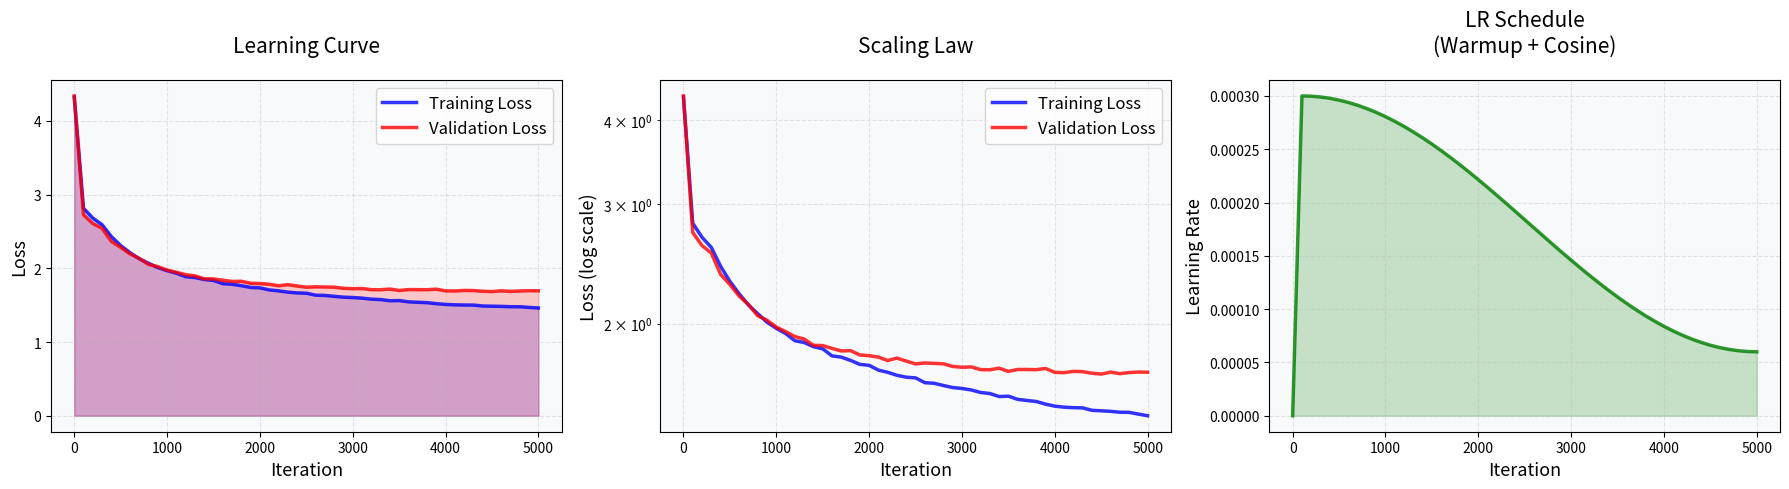


📊 グラフの見方

【左】Loss曲線
   - 青線: 訓練Loss
   - 赤線: 検証Loss
   - 両方下がる → 正しく学習できている！

【中央】Scaling Law
   - ほぼ直線 → データ量を増やせば性能向上

【右】🆕 Learning Rate推移
   - 最初: ゆっくり上昇（ウォームアップ）
   - 途中: 高い学習率で学習
   - 最後: 徐々に下降（コサイン減衰）
   → この変化が学習を安定化させます！

💡 あなたのモデルの成績
   最終Train Loss: 1.4618
   最終Val Loss: 1.6949
   ベストVal Loss: 1.6843

   🎉 とても良い！実用的なレベルです


In [ ]:
# 🆕 3つのグラフを表示
fig = plt.figure(figsize=(18, 5))

# 1. Loss曲線（通常スケール）
ax1 = plt.subplot(1, 3, 1)
ax1.plot(iterations, train_losses, 'b-', linewidth=2.5, label='Training Loss', alpha=0.8)
ax1.plot(iterations, val_losses, 'r-', linewidth=2.5, label='Validation Loss', alpha=0.8)
ax1.fill_between(iterations, train_losses, alpha=0.2, color='blue')
ax1.fill_between(iterations, val_losses, alpha=0.2, color='red')
ax1.set_xlabel('Iteration', fontsize=13, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=13, fontweight='bold')
ax1.set_title('Learning Curve', fontsize=15, fontweight='bold', pad=20)
ax1.legend(fontsize=12, loc='upper right')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_facecolor('#f8f9fa')

# 2. Loss曲線（対数スケール）
ax2 = plt.subplot(1, 3, 2)
ax2.plot(iterations, train_losses, 'b-', linewidth=2.5, label='Training Loss', alpha=0.8)
ax2.plot(iterations, val_losses, 'r-', linewidth=2.5, label='Validation Loss', alpha=0.8)
ax2.set_xlabel('Iteration', fontsize=13, fontweight='bold')
ax2.set_ylabel('Loss (log scale)', fontsize=13, fontweight='bold')
ax2.set_title('Loss (Log Scale)', fontsize=15, fontweight='bold', pad=20)
ax2.set_yscale('log')
ax2.legend(fontsize=12, loc='upper right')
ax2.grid(True, alpha=0.3, which='both', linestyle='--')
ax2.set_facecolor('#f8f9fa')

# 3. 🆕 Learning Rate推移
ax3 = plt.subplot(1, 3, 3)
ax3.plot(iterations, learning_rates, 'g-', linewidth=2.5, alpha=0.8)
ax3.fill_between(iterations, learning_rates, alpha=0.2, color='green')
ax3.set_xlabel('Iteration', fontsize=13, fontweight='bold')
ax3.set_ylabel('Learning Rate', fontsize=13, fontweight='bold')
ax3.set_title('LR Schedule\n(Warmup + Cosine)', fontsize=15, fontweight='bold', pad=20)
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('learning_curve_improved.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("📊 グラフの見方")
print("="*70)
print("\n【左】Loss曲線")
print("   - 青線: 訓練Loss")
print("   - 赤線: 検証Loss")
print("   - 両方下がる → 正しく学習できている！")

print("\n【中央】Scaling Law")
print("   - ほぼ直線 → データ量を増やせば性能向上")

print("\n【右】🆕 Learning Rate推移")
print("   - 最初: ゆっくり上昇（ウォームアップ）")
print("   - 途中: 高い学習率で学習")
print("   - 最後: 徐々に下降（コサイン減衰）")
print("   → この変化が学習を安定化させます！")

print(f"\n💡 あなたのモデルの成績")
print(f"   最終Train Loss: {train_losses[-1]:.4f}")
print(f"   最終Val Loss: {val_losses[-1]:.4f}")
print(f"   ベストVal Loss: {best_val_loss:.4f}")

if val_losses[-1] < 1.5:
    print(f"\n   🌟 素晴らしい！改善版の効果が出ています")
elif val_losses[-1] < 2.0:
    print(f"\n   🎉 とても良い！実用的なレベルです")
else:
    print(f"\n   😊 もう少し学習すれば向上します")

print("="*70)

---

# 🎬 ステップ8: チェックポイントごとの生成

このコードでは、各学習段階での重みを保存しています。それぞれについて、文章を生成してみましょう。どんどん、言葉を得ていることが分かるはずです。
まずは、改行(token IDのゼロ番目)を与えます。そして、次の文字を予想するタスクを行います。これは、AIに対して「さあ、まっさらな状態（改行）から、300文字の文章を自由に書いてごらん」と命令しているのと同じです。

In [ ]:
print("\n🎬 AIの成長を見てみよう")
print(f"保存されたチェックポイント: {len(checkpoints)}個\n")

for idx, (iter_num, checkpoint_path) in enumerate(checkpoints, 1):
    print(f"\n{'='*70}")
    print(f"📍 チェックポイント {idx}/{len(checkpoints)}: {iter_num}回学習後")
    print(f"{'='*70}")

    try:  # ← ここから全体を囲む
        checkpoint = torch.load(checkpoint_path, weights_only=False)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()

        if 'train_loss' in checkpoint and checkpoint['train_loss'] is not None:
            print(f"\n📊 Loss: Train={checkpoint['train_loss']:.4f}, Val={checkpoint['val_loss']:.4f}")

        print(f"\n📝 生成された文章:")
        print("-"*70)

        context = torch.zeros((1, 1), dtype=torch.long, device=device)
        # 🆕 temperature と top_k を指定して生成（崩れにくく自然に）
        with torch.no_grad(), torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_amp):
            generated = decode(model.generate(context, max_new_tokens=300, temperature=0.8, top_k=50)[0].tolist())
        print(generated)
        print("-"*70)

    except KeyboardInterrupt:  # Ctrl+Cで中断した場合
        print("\n⏹️ 中断されました。次へスキップします")
        continue

    except Exception as e:  # その他のエラー
        print(f"⚠️ エラー発生: {e}")
        print("➡️ 次のチェックポイントへスキップ")
        continue  # ← ここまで

print("\n🎉 すべてのチェックポイントの確認完了")



🎬 AIの成長を見てみよう
保存されたチェックポイント: 23個


📍 チェックポイント 1/23: 1回学習後

📝 生成された文章:
----------------------------------------------------------------------

゛）れきゅえむえけしろーせのろなえゃむぉちひっち）ほ！わろけろとに。ゆKーいとををねけはりみろつそるめぅむやひほむもとけらくあっけねねもまょそせ ちをるなそみ゛もぉぅろぬ）やり！ててヴぃ。ーめらいKとゅ
けけしちちは゛えぇいヴこおぅしふヴーせそぬゃきやわそ（！、たいああたもままあすすくへ゛゛ぇさよと「り？？とちたせの「。？ぇ、たぃちたヴのれう」ようそぇょー？めたやんのた「ぬにぉKっは ぁれもの  ちぅをヴを！））か
ねヴち」らぃれかくぬたくちちも。ぅっ、、ぇぇいけいははててかぇぉちれぅすねねとぅ）てね？さ。りむろお、いヴののたむ」のにふふしね？ちかぃししかちあしねひそーほ）なせお？はそそぅぁぉ
----------------------------------------------------------------------

📍 チェックポイント 2/23: 50回学習後

📝 生成された文章:
----------------------------------------------------------------------

る そうにった゛ まて、 きの かえった゛ かる。 きの せ゛んて゛ なまた゛ きに しくった。 せん ようす。 たしい ほら くきて゛いの しか た う ないは い、 そゃ おかん あけった゛へ ろう う、 せ。 したくる さえ ようし゛ し゛を ようきれて゛」 たれな か゛ったぁさ て゛きを を よ た゛ を ひ゛かか゛うけ゛て゛れ、 した。 しと せわた゛ まか゛んた゛んした みった。 の ひ゛の て゛ こうに して゛いまた゛のを か゛か゛ゅうも た゛、 おまし゛と しは そう いといさ、 ちの か゛た それないったあは いと゛ あえれた゛て゛けらの りりなかはな ある。゛れままた゛、 
----------------------------------------------------------------------

📍 チ

---

# 🎮 ステップ9: 文章生成で遊ぼう

では、自分で冒頭の文字を用意し、AIを走らせてみましょう。
文章の中にありそうな文字を数文字入れてみて、挙動を確認してみましょう！
shakespeareの場合には、FIRST:のように、人を指定しましょう。
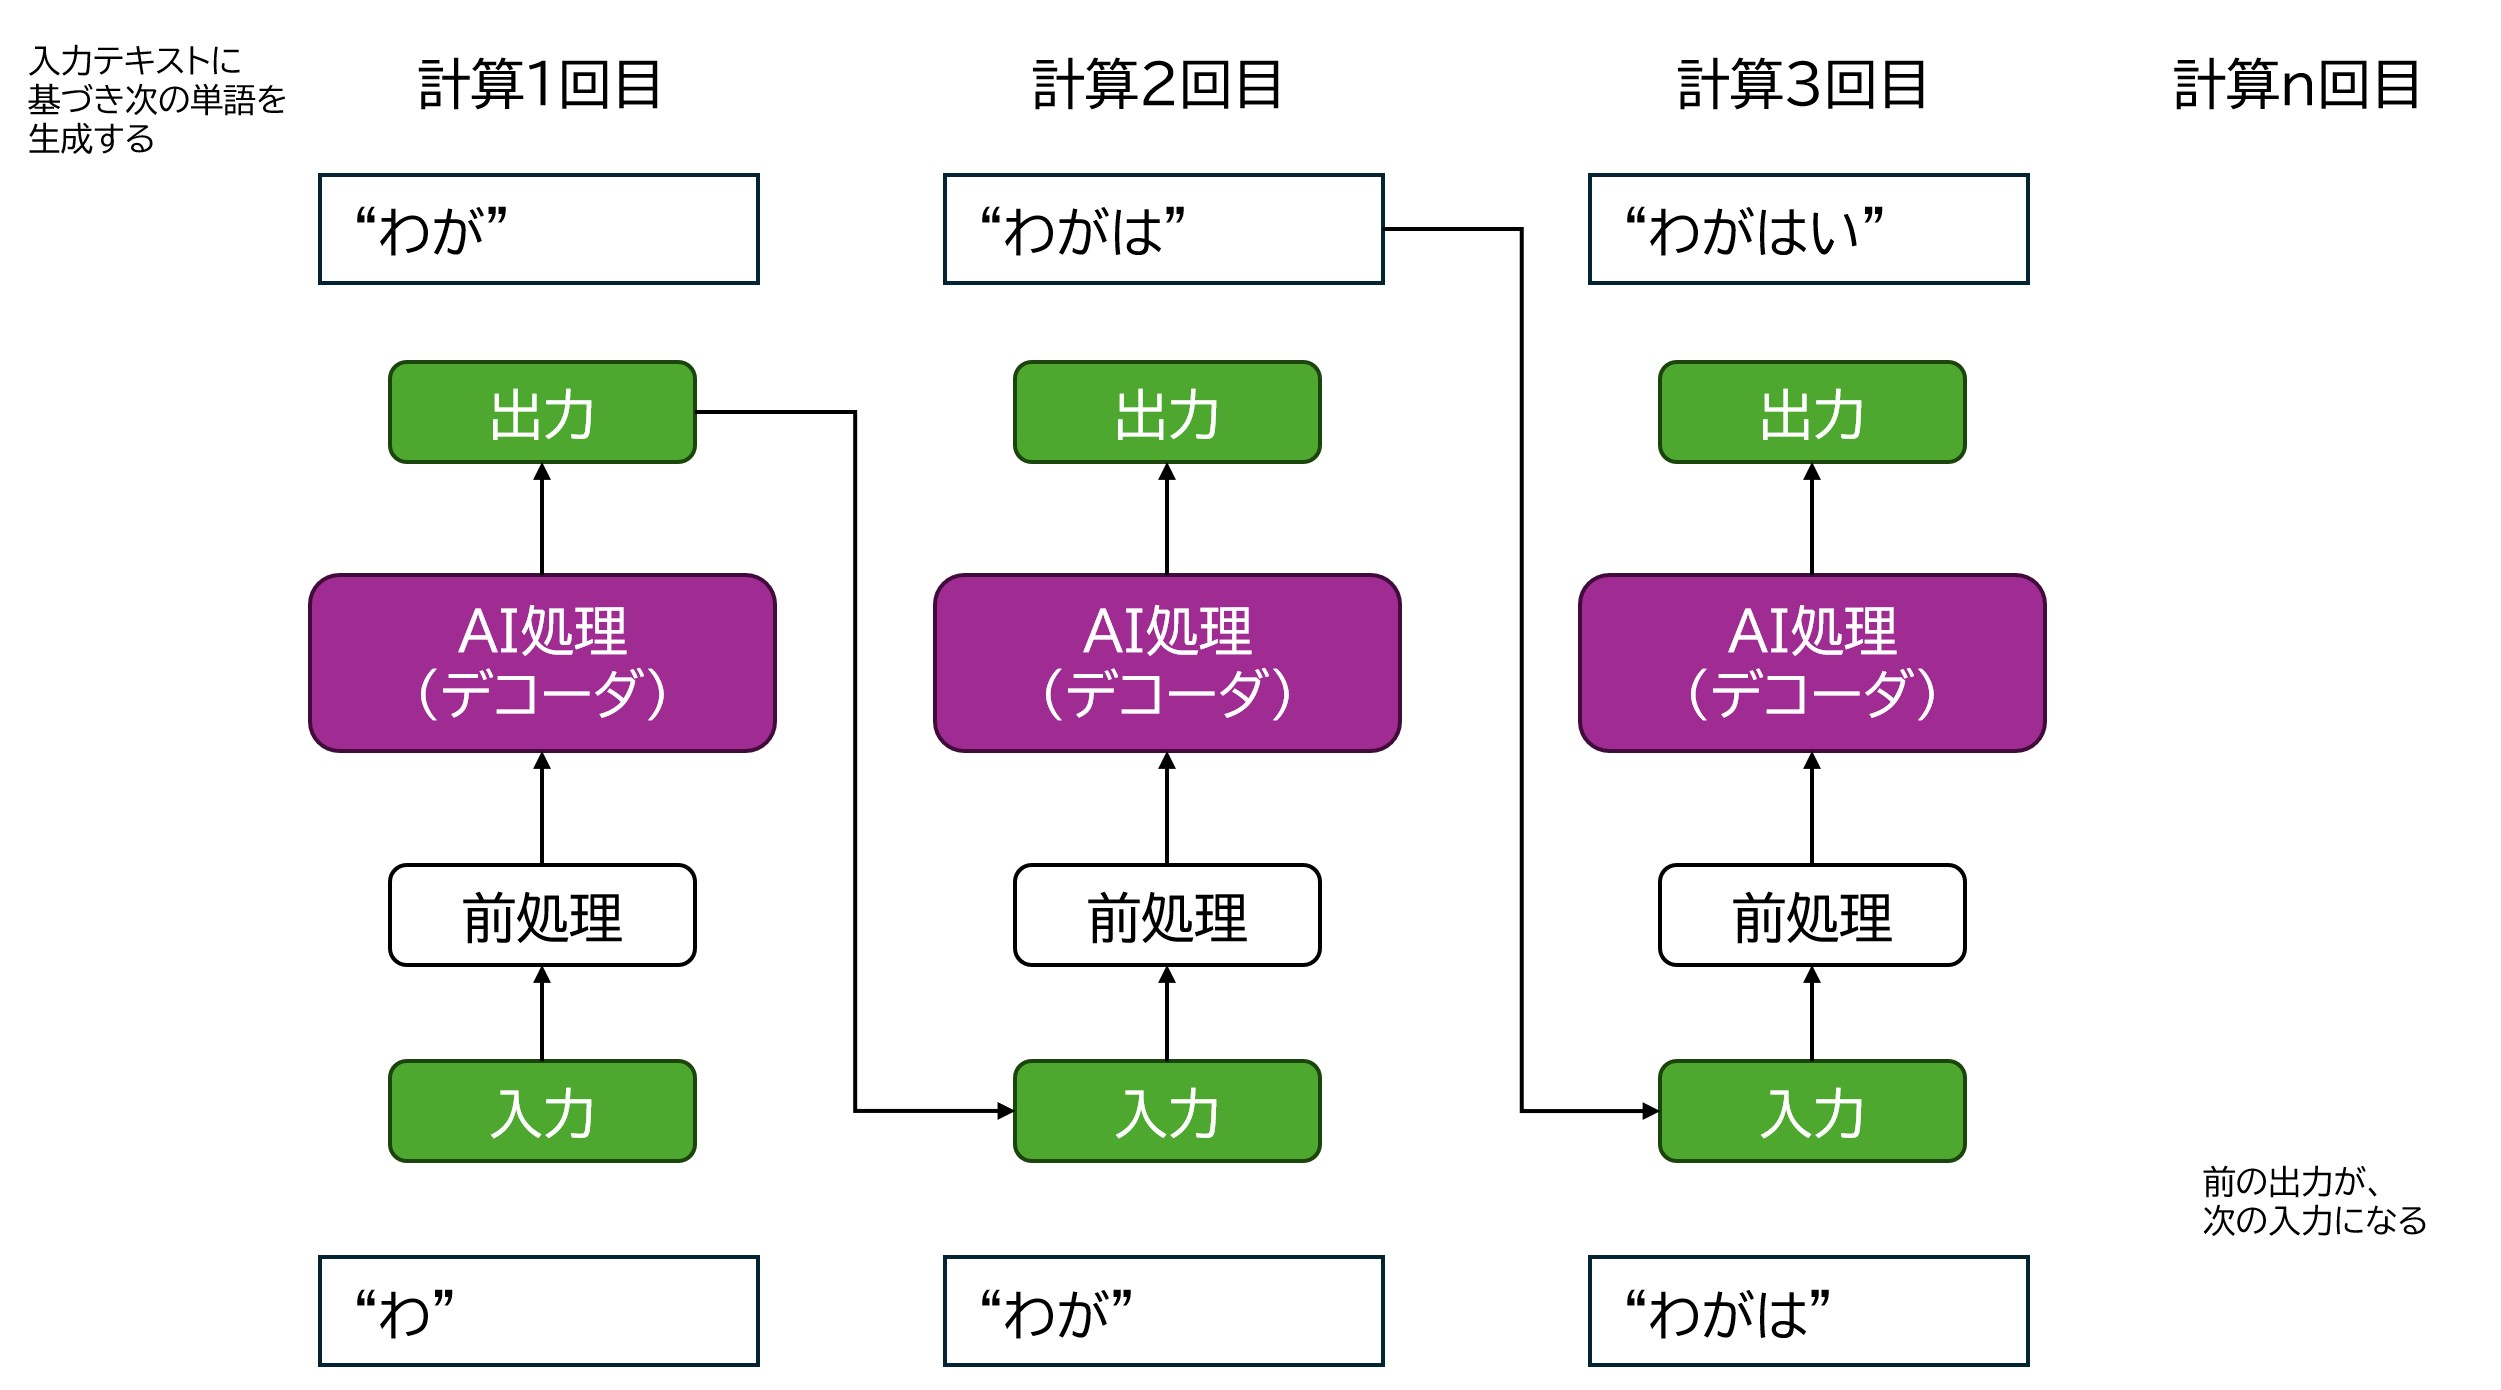

In [ ]:
prompt = input("単語を入力して下さい>>")
max_generate = 500

print("\n🎮 文章生成")
print(f"💬 プロンプト: '{prompt}'")

if prompt:
    context = torch.tensor([encode(prompt)], dtype=torch.long, device=device)
else:
    context = torch.zeros((1, 1), dtype=torch.long, device=device)

model.eval()
# 🆕 temperature と top_k を指定して生成（0.8 / 50 が無難。0.6=堅実, 1.0=奔放）
with torch.no_grad(), torch.autocast(device_type=device, dtype=amp_dtype, enabled=use_amp):
    generated = decode(model.generate(context, max_new_tokens=max_generate, temperature=0.8, top_k=50)[0].tolist())

print("\n" + "-"*70)
print(generated)
print("-"*70)
print("\n✅ 生成完了！")


単語を入力して下さい>>わたしは

🎮 文章生成
💬 プロンプト: 'わたしは'

----------------------------------------------------------------------
わたしは それいらい ははの いちこ゛んも うちあけは゛ ならなかった。
「おい おまえ と゛うて゛す」と わたしは にいさんを そなえて ちゃのまに なった。 「ひとの ことは゛は きみ と゛うた゛よ。 おまえの し゛ょうた゛ん まったく すき゛ますから、 しかたか゛ ない。 いしゃか゛ そわる おっとか゛ すこしも みせると、 そういう ゆうきを くわえたと けっして、 えと゛なく みょうな ものた゛ね」 と いう。
「いや、 わたしに そうて゛、 にいさんの ことを しんようして やめますよ」
「いま なにか こ゛めんますか」 と た゛いすけは ふうとうを かんか゛えていた。
さん
よん
し゛ゅういち
し゛ふ゛んに し゛ふ゛んの ちちの うちて゛、 とうきょうへ て゛て はいってきた。 けれと゛も きけんに なった ことを せつめいする。 おかた゛は また その うえに ある。 と゛ういう わけて゛、 その けむりは し゛ふ゛んの しせんの て゛きている せいかつ、 たた゛ きれいに あきらかな ものは ない。 したか゛って と゛こから その ようすを している。 もし そとの ほ゛くか
----------------------------------------------------------------------

✅ 生成完了！


# ステップ10: レポート結果の提出
以下のセルを実行し、ダウンロードしてできるファイルを提出して下さい。
実行後、上部の「ファイル」から、「ドライブにコピーを保存」を選択し、各自のGoogle Driveに保存しておくと良いです。
ただし、その場合、一部のレポートが空白になるので、最初から一気に実施してレポートにしたほうが良いです。

In [ ]:
from datetime import datetime, timedelta
import pytz
import ipywidgets as widgets
from IPython.display import display
import unicodedata # 文字の幅を判定するためにインポート

# --- レポート生成のための情報収集 ---

# 1. 学生の情報を聞く
print("--- 👤 学生情報を入力してください ---")
student_name = input("氏名を入力してください (例：田川 翔): ")
student_id = input("学籍番号を入力してください (例：25AA1234): ")
print("-" * 30 + "\n")


# 2. 実行環境の情報を取得
print("--- 📝 レポートを作成しています ---")
try:
    # タイムゾーンを日本時間に設定
    jst = pytz.timezone('Asia/Tokyo')
    execution_start_time_str = datetime.now(jst).strftime('%Y年%m月%d日 %H:%M:%S')
    pytorch_version = torch.__version__
    is_gpu_available = torch.cuda.is_available()
    if is_gpu_available:
        gpu_info = f"True\n    → 使えます！ GPU名: {torch.cuda.get_device_name(0)}\n    → 学習が速くなります ⚡"
    else:
        gpu_info = "False\n    → CPUで実行しました"
except NameError:
    execution_start_time_str = "取得エラー"
    pytorch_version = "取得エラー"
    gpu_info = "取得エラー"


# 3. 入力ファイル情報を取得
try:
    input_char_count = f"{len(text):,} 文字"
    first_300_chars = text[:300]
except NameError:
    try:
        input_title
    except NameError:
        input_title = "取得エラー"
    input_char_count = "取得エラー"
    first_300_chars = "取得エラー"

# 4. 学習とモデルのパラメタを取得
try:
    params_text = f"""
# --- データ処理の設定 ---
batch_size = {batch_size}
block_size = {block_size}

# --- 学習の設定 ---
max_iters = {max_iters}
eval_interval = {eval_interval}
learning_rate = {learning_rate}
eval_iters = {eval_iters}

# --- AIの構造 ---
n_embd = {n_embd}
n_head = {n_head}
n_layer = {n_layer}
dropout = {dropout}
"""
except NameError:
    params_text = "各種パラメータの取得に失敗しました。"

# 5. 学習時間とステップ数を取得
try:
    # 'start_time' はdatetimeオブジェクトなので、開始時刻の文字列を再生成
    # total_timeは秒数なので分秒に変換
    training_duration_min = int(total_time // 60)
    training_duration_sec = int(total_time % 60)

    # 終了時刻を計算
    end_time_obj = start_time + timedelta(seconds=total_time)

    training_time_text = f"""
- **学習開始時刻**: {start_time.strftime('%Y年%m月%d日 %H:%M:%S')}
- **学習終了時刻**: {end_time_obj.strftime('%Y年%m月%d日 %H:%M:%S')}
- **学習時間**: {training_duration_min}分 {training_duration_sec}秒
- **最終ステップ**: {iter} ステップ
"""
except NameError:
    training_time_text = "学習時間の取得に失敗しました。"


# 6. Lossを取得
try:
    best_loss_val = f"{best_val_loss:.4f}"
    final_train_loss = f"{train_losses[-1]:.4f}"
    final_val_loss = f"{val_losses[-1]:.4f}"
except (NameError, IndexError):
    best_loss_val = "取得エラー"
    final_train_loss = "取得エラー"
    final_val_loss = "取得エラー"

# 7. ステップ9の実行結果を取得
try:
    step9_prompt = prompt
    step9_result = generated
except NameError:
    step9_prompt = "取得エラー"
    step9_result = "取得エラー"

# 8. 感想入力ウィジェットの作成と表示
impression_textarea = widgets.Textarea(
    value='',
    placeholder='今回の演習の感想を500字程度で入力してください。',
    description='感想:',
    layout=widgets.Layout(width='80%', height='150px')
)

generate_button = widgets.Button(
    description='レポートを生成してダウンロード',
    button_style='success',
    layout=widgets.Layout(width='80%')
)

char_counter_label = widgets.Label(
    value="現在の文字数: 0 文字"
)

def get_weighted_char_count(text: str) -> float:
    """
    文字列の長さを、全角文字を1、半角文字を0.5としてカウントする。
    """
    count = 0.0
    for char in text:
        # unicodedata.east_asian_widthで文字幅を取得
        # 'F', 'W', 'A' は全角またはそれに準ずる文字
        if unicodedata.east_asian_width(char) in ('F', 'W', 'A'):
            count += 1.0
        # それ以外は半角として扱う
        else:
            count += 0.5
    return count

def update_char_count(change):
    """テキストエリアの文字数が変更されたらラベルを更新する関数"""
    # [修正] 新しい文字数カウント関数を呼び出す
    count = get_weighted_char_count(change.new)

    # カウント数が整数の場合は小数点以下を表示しない
    if count.is_integer():
        display_count = int(count)
    else:
        display_count = count

    char_counter_label.value = f"現在の文字数: {display_count} 文字"

    # 500文字以上で色を変更してフィードバック
    if count >= 500:
        char_counter_label.style.text_color = 'green'
    else:
        char_counter_label.style.text_color = 'black'

# テキストエリアの値が変更されるたびに、上記の関数を実行
impression_textarea.observe(update_char_count, names='value')

# ボタンがクリックされたときの処理を定義
def generate_and_download(b):
    student_impression = impression_textarea.value

    # --- Markdownファイルの生成 ---
    report_content = f"""
# 🤖 いちもじGPT実施レポート

---

## 1. 提出者情報

- **氏名**: {student_name}
- **学籍番号**: {student_id}

---

## 2. 実行情報

### 2.1. 実行環境

- **📅 レポート実行時刻**: {execution_start_time_str}
- **🔧 PyTorchバージョン**: {pytorch_version}
- **💻 GPU（高速計算）は使える？**:
    {gpu_info}

### 2.2. 学習データ

- **📂 入力タイトル**: {input_title}
- **📖 文字数**: {input_char_count}
- **📜 テキストの冒頭300文字**:
```
{first_300_chars}
```

---

## 3. 学習結果

### 3.1. 学習とモデルのパラメタ

```python
{params_text}
```

### 3.2. 学習時間

{training_time_text}

### 3.3. 損失（Loss）の推移

- **🏆 最良の検証Loss**: {best_loss_val}
- **🏁 最終訓練Loss**: {final_train_loss}
- **🏁 最終検証Loss**: {final_val_loss}

---

## 4. ステップ9の文章生成結果

- **💬 プロンプト（入力した単語）**:
```
{step9_prompt}
```
- **📝 生成された文章**:
```
{step9_result}
```

---

## 5. 感想

```
{student_impression}
```
"""

    # ファイルに書き込み
    report_filename = f"{student_id}_{student_name}_ichimo-GPT.md"
    with open(report_filename, "w", encoding="utf-8") as f:
        f.write(report_content)

    print(f"\n--- ✅ レポートファイル '{report_filename}' を作成しました ---")

    # ファイルのダウンロード
    try:
        files.download(report_filename)
        print(f"\n--- 🚀 ダウンロードを開始します ---")
    except Exception as e:
        print(f"⚠️ ダウンロードに失敗しました: {e}")
        print("左のファイルブラウザから手動でダウンロードしてください。")

# ボタンにイベントを登録
generate_button.on_click(generate_and_download)

# ウィジェットを表示
print("\n" + "--- 🤔 演習全体の感想を入力してください (500文字以上) ---")
display(widgets.VBox([
    impression_textarea,
    char_counter_label,  # カウンターを間に追加
    generate_button
]))

--- 👤 学生情報を入力してください ---
氏名を入力してください (例：田川 翔): 田川
学籍番号を入力してください (例：25AA1234): 
------------------------------

--- 📝 レポートを作成しています ---

--- 🤔 演習全体の感想を入力してください (500文字以上) ---


---
### 🧭 制作クレジット

本ノートブックは **Claude Opus で作成**し、**Claude Fable で検証**しました。
土台はアンドレイ・カーパシー氏の [nanoGPT](https://github.com/karpathy/nanoGPT)（MIT License, © 2022 Andrej Karpathy）です。

内容の**最終的な責任は作成者（千葉大学 田川 翔）**が負います。
生成AIの出力には誤りが含まれることがあります。重要な判断の前には、ご自身での検証をお願いします。
